### LLM Extension Plots

### Packages

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import os
import fredapi
from fredapi import Fred
import numpy as np 

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Path to Data

In [2]:
# File Path
LLM_Extension_Excel_path = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Extension LLM Classification Task/Fed Side//Excel Sentences Results")
# Data Frame
LLM_Extension_Excel_data = pd.read_excel(LLM_Extension_Excel_path / "fed_statements_presconf_WITH_LLM_LABELS.xlsx")
LLM_Extension_Excel_Speeches = pd.read_excel(LLM_Extension_Excel_path / "fed_speeches_WITH_LLM_LABELS.xlsx")
LLM_Extension_Excel_data.head(10)

,source,orig_row,id,raw_text,doc_type,clean_text,sentence,label,gold_collapsed,llm_majority,...,mistral-small__p4_analyst_json,mistral-small__p5_analyst_fewshot,date,exact_match,file,speaker,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,statements,0,2011.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"In these circumstances, and against the backgr...",H,H,N,...,N,N,2000-02-02 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,statements,1,2009.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Although core measures of prices are rising sl...,H,H,D,...,D,D,2000-03-21 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,statements,2,2006.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Against the background of its long-term goals ...,H,H,H,...,N,N,2000-05-16 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,statements,3,2008.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Recent data suggest that the expansion of aggr...,N,N,N,...,N,N,2000-05-16 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,statements,4,2004.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,The data also have indicated that more rapid a...,N,N,D,...,D,D,2000-06-28 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,statements,5,1997.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,Recent data have indicated that the expansion ...,H,H,N,...,N,N,2000-08-22 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,statements,6,1999.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"Moreover, the increase in energy prices, thoug...",H,H,H,...,H,H,2000-08-22 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
7,statements,7,1996.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,The Federal Open Market Committee at its meeti...,H,H,N,...,N,N,2000-08-22 00:00:00,1.0,NaN,NaN,NaN,NaN,NaN,NaN
8,statements,8,1995.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"Nonetheless, to date the easing of demand pres...",H,H,H,...,D,D,2000-10-03 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9,statements,9,1993.0,The Federal Open Market Committee at its meeti...,statement,The Federal Open Market Committee at its meeti...,"The Committee, accordingly, continues to see a...",D,D,H,...,H,H,2000-10-03 00:00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
LLM_Extension_Excel_data.columns

Index(['source', 'orig_row', 'id', 'raw_text', 'doc_type', 'clean_text',
       'sentence', 'label', 'gold_collapsed', 'llm_majority',
       'claude-haiku__p1_analyst_direct', 'claude-haiku__p2_analyst_rubric',
       'claude-haiku__p3_analyst_rules', 'claude-haiku__p4_analyst_json',
       'claude-haiku__p5_analyst_fewshot', 'claude-sonnet__p1_analyst_direct',
       'claude-sonnet__p2_analyst_rubric', 'claude-sonnet__p3_analyst_rules',
       'claude-sonnet__p4_analyst_json', 'claude-sonnet__p5_analyst_fewshot',
       'deepseek-chat__p1_analyst_direct', 'deepseek-chat__p2_analyst_rubric',
       'deepseek-chat__p3_analyst_rules', 'deepseek-chat__p4_analyst_json',
       'deepseek-chat__p5_analyst_fewshot',
       'deepseek-reasoner__p1_analyst_direct',
       'deepseek-reasoner__p2_analyst_rubric',
       'deepseek-reasoner__p3_analyst_rules',
       'deepseek-reasoner__p4_analyst_json',
       'deepseek-reasoner__p5_analyst_fewshot',
       'gpt-5-mini__p1_analyst_direct', 'gpt-5-

### Anthropic Model Analysis

In [4]:
Anthropic_Model_Analysis_df = LLM_Extension_Excel_data[[
    'date',
    'label',
    'claude-sonnet__p1_analyst_direct',
    'claude-sonnet__p2_analyst_rubric',
    'claude-sonnet__p3_analyst_rules',
    'claude-sonnet__p4_analyst_json',
    'claude-sonnet__p5_analyst_fewshot',
    'claude-haiku__p1_analyst_direct',
    'claude-haiku__p2_analyst_rubric',
    'claude-haiku__p3_analyst_rules',
    'claude-haiku__p4_analyst_json',
    'claude-haiku__p5_analyst_fewshot'
]].copy()

Anthropic_Model_Analysis_df.head(10)

,date,label,claude-sonnet__p1_analyst_direct,claude-sonnet__p2_analyst_rubric,claude-sonnet__p3_analyst_rules,claude-sonnet__p4_analyst_json,claude-sonnet__p5_analyst_fewshot,claude-haiku__p1_analyst_direct,claude-haiku__p2_analyst_rubric,claude-haiku__p3_analyst_rules,claude-haiku__p4_analyst_json,claude-haiku__p5_analyst_fewshot
0,2000-02-02 00:00:00,H,H,H,H,H,H,N,H,H,N,N
1,2000-03-21 00:00:00,H,D,D,NaN,D,D,D,D,N,N,D
2,2000-05-16 00:00:00,H,H,H,H,H,H,H,H,H,H,H
3,2000-05-16 00:00:00,N,D,N,NaN,N,D,D,D,N,N,N
4,2000-06-28 00:00:00,N,D,D,NaN,D,D,D,D,N,N,D
5,2000-08-22 00:00:00,H,N,N,N,N,D,N,D,N,N,N
6,2000-08-22 00:00:00,H,H,H,H,H,H,H,H,H,H,H
7,2000-08-22 00:00:00,H,N,N,N,N,N,N,N,N,N,N
8,2000-10-03 00:00:00,H,H,N,H,H,H,H,H,N,N,N
9,2000-10-03 00:00:00,D,H,H,H,H,H,H,H,H,H,H


FRED Data Retrieval

In [5]:
fred_api_key = Fred(api_key="88a8844ca93e8780390f1ea6641677f3")
# Start Dates
start_date = "2000-01-01"
# End Dates
end_date = "2026-01-01"
inflation_data_ids = {"US_Annual_CPI": "FPCPITOTLZGUSA", "Ten_Yr_US_Brk_even": "T10YIEM"}
# Making the data frame
raw_monthly_inflation_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
    for name, sid in inflation_data_ids.items()},
    axis=1
)
# Converting the raw monthly data into daily data and keeping the time frame consistent with the rest of the data
daily_inflation_data = raw_monthly_inflation_data.resample('ME').ffill()


# Api Key
fred_api_key = Fred(api_key="88a8844ca93e8780390f1ea6641677f3")
# Start Dates
start_date = "2000-01-01"
# End Dates
end_date = "2026-01-01"
emply_data_ids = {"US_Unemploy": "UNRATE",}
# Making the data frame
raw_monthly_unemploy_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)
    for name, sid in emply_data_ids.items()},
    axis=1
)
# Converting the raw monthly data into daily data and keeping the time frame consistent with the rest of the data
daily_unemploy_data = raw_monthly_unemploy_data.resample('ME').ffill()


Fred_Data_df = pd.concat([daily_inflation_data, daily_unemploy_data], axis=1)   
Fred_Data_df.head(10)

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_41130/593648959.py:8: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  raw_monthly_inflation_data = pd.concat({name: fred_api_key.get_series(sid, observation_start=start_date, observation_end=end_date)


,US_Annual_CPI,Ten_Yr_US_Brk_even,US_Unemploy
2000-01-31,3.376857,NaN,4.0
2000-02-29,3.376857,NaN,4.1
2000-03-31,3.376857,NaN,4.0
2000-04-30,3.376857,NaN,3.8
2000-05-31,3.376857,NaN,4.0
2000-06-30,3.376857,NaN,4.0
2000-07-31,3.376857,NaN,4.0
2000-08-31,3.376857,NaN,4.1
2000-09-30,3.376857,NaN,3.9
2000-10-31,3.376857,NaN,3.9


Building the indicie

In [6]:
## Indicies Conversion
Anthropic_Model_Analysis_df["date"] = pd.to_datetime(
    Anthropic_Model_Analysis_df["date"], errors="coerce"
)

def build_index(df, freq, label_col):
    """Measure per period. freq: 'Q' = quarterly, 'A' = yearly."""
    counts = df.groupby([pd.Grouper(key="date", freq=freq), label_col]).size().unstack(fill_value=0)
    index = (counts.get("H", 0) - counts.get("D", 0)) / counts.sum(axis=1)
    return index



In [7]:
model_cols_all = [
    'claude-haiku__p1_analyst_direct', 'claude-haiku__p2_analyst_rubric',
    'claude-haiku__p3_analyst_rules', 'claude-haiku__p4_analyst_json',
    'claude-haiku__p5_analyst_fewshot', 'claude-sonnet__p1_analyst_direct',
    'claude-sonnet__p2_analyst_rubric', 'claude-sonnet__p3_analyst_rules',
    'claude-sonnet__p4_analyst_json', 'claude-sonnet__p5_analyst_fewshot',
    'deepseek-chat__p1_analyst_direct', 'deepseek-chat__p2_analyst_rubric',
    'deepseek-chat__p3_analyst_rules', 'deepseek-chat__p4_analyst_json',
    'deepseek-chat__p5_analyst_fewshot',
    'deepseek-reasoner__p1_analyst_direct', 'deepseek-reasoner__p2_analyst_rubric',
    'deepseek-reasoner__p3_analyst_rules', 'deepseek-reasoner__p4_analyst_json',
    'deepseek-reasoner__p5_analyst_fewshot',
    'gpt-5-mini__p1_analyst_direct', 'gpt-5-mini__p2_analyst_rubric',
    'gpt-5-mini__p3_analyst_rules', 'gpt-5-mini__p4_analyst_json',
    'gpt-5-mini__p5_analyst_fewshot', 'gpt-5.1__p1_analyst_direct',
    'gpt-5.1__p2_analyst_rubric', 'gpt-5.1__p3_analyst_rules',
    'gpt-5.1__p4_analyst_json', 'gpt-5.1__p5_analyst_fewshot',
    'mistral-large__p1_analyst_direct', 'mistral-large__p2_analyst_rubric',
    'mistral-large__p3_analyst_rules', 'mistral-large__p4_analyst_json',
    'mistral-large__p5_analyst_fewshot', 'mistral-small__p1_analyst_direct',
    'mistral-small__p2_analyst_rubric', 'mistral-small__p3_analyst_rules',
    'mistral-small__p4_analyst_json', 'mistral-small__p5_analyst_fewshot'
]

All_Model_Analysis_df = LLM_Extension_Excel_data[['date', 'label'] + model_cols_all].copy()
All_Model_Analysis_df.head(10)

,date,label,claude-haiku__p1_analyst_direct,claude-haiku__p2_analyst_rubric,claude-haiku__p3_analyst_rules,claude-haiku__p4_analyst_json,claude-haiku__p5_analyst_fewshot,claude-sonnet__p1_analyst_direct,claude-sonnet__p2_analyst_rubric,claude-sonnet__p3_analyst_rules,...,mistral-large__p1_analyst_direct,mistral-large__p2_analyst_rubric,mistral-large__p3_analyst_rules,mistral-large__p4_analyst_json,mistral-large__p5_analyst_fewshot,mistral-small__p1_analyst_direct,mistral-small__p2_analyst_rubric,mistral-small__p3_analyst_rules,mistral-small__p4_analyst_json,mistral-small__p5_analyst_fewshot
0,2000-02-02 00:00:00,H,N,H,H,N,N,H,H,H,...,N,H,H,N,N,N,N,H,N,N
1,2000-03-21 00:00:00,H,D,D,N,N,D,D,D,NaN,...,N,H,N,N,D,N,H,H,D,D
2,2000-05-16 00:00:00,H,H,H,H,H,H,H,H,H,...,H,H,H,D,H,H,H,H,N,N
3,2000-05-16 00:00:00,N,D,D,N,N,N,D,N,NaN,...,N,N,N,N,D,N,N,N,N,N
4,2000-06-28 00:00:00,N,D,D,N,N,D,D,D,NaN,...,N,H,D,D,D,N,H,D,D,D
5,2000-08-22 00:00:00,H,N,D,N,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
6,2000-08-22 00:00:00,H,H,H,H,H,H,H,H,H,...,H,H,H,H,H,H,H,H,H,H
7,2000-08-22 00:00:00,H,N,N,N,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
8,2000-10-03 00:00:00,H,H,H,N,N,N,H,N,H,...,N,N,N,N,N,N,N,H,D,D
9,2000-10-03 00:00:00,D,H,H,H,H,H,H,H,H,...,H,H,H,H,H,H,H,H,H,H


In [8]:
All_Model_Analysis_df["date"] = pd.to_datetime(
    All_Model_Analysis_df["date"], errors="coerce"
)

model_cols_full = ['label'] + model_cols_all

indices_all = {
    col: build_index(All_Model_Analysis_df, freq="QE", label_col=col)
    for col in model_cols_full
}

index_df_all = pd.DataFrame(indices_all)
index_df_all.head(10)

,label,claude-haiku__p1_analyst_direct,claude-haiku__p2_analyst_rubric,claude-haiku__p3_analyst_rules,claude-haiku__p4_analyst_json,claude-haiku__p5_analyst_fewshot,claude-sonnet__p1_analyst_direct,claude-sonnet__p2_analyst_rubric,claude-sonnet__p3_analyst_rules,claude-sonnet__p4_analyst_json,...,mistral-large__p1_analyst_direct,mistral-large__p2_analyst_rubric,mistral-large__p3_analyst_rules,mistral-large__p4_analyst_json,mistral-large__p5_analyst_fewshot,mistral-small__p1_analyst_direct,mistral-small__p2_analyst_rubric,mistral-small__p3_analyst_rules,mistral-small__p4_analyst_json,mistral-small__p5_analyst_fewshot
date,,,,,,,,,,,,,,,,,,,,,
2000-03-31,1.000000,-0.500000,0.000000,0.500000,0.000000,-0.500000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,0.500000,0.000000,-0.500000,0.000000,0.500000,1.000000,-0.500000,-0.500000
2000-06-30,0.333333,-0.333333,-0.333333,0.333333,0.333333,0.000000,-0.333333,0.000000,1.000000,0.000000,...,0.333333,0.666667,0.000000,-0.666667,-0.333333,0.333333,0.666667,0.000000,-0.333333,-0.333333
2000-09-30,1.000000,0.333333,0.000000,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,...,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
2000-12-31,0.142857,0.142857,0.000000,0.142857,0.142857,-0.142857,0.285714,0.142857,0.166667,-0.142857,...,-0.142857,-0.142857,-0.142857,-0.142857,-0.142857,-0.142857,0.000000,0.000000,-0.285714,-0.285714
2001-03-31,0.250000,0.750000,0.750000,0.500000,0.000000,0.250000,0.500000,0.500000,0.250000,-0.500000,...,0.000000,0.500000,-0.750000,-0.750000,-0.750000,0.000000,0.500000,0.500000,0.000000,0.000000
2001-06-30,-0.200000,-0.400000,0.000000,0.000000,-0.400000,-0.200000,0.000000,0.000000,-0.500000,-0.400000,...,-0.400000,-0.200000,-0.400000,-0.400000,-0.400000,0.000000,-0.200000,-0.200000,-0.400000,-0.200000
2001-09-30,0.600000,-0.400000,0.400000,0.000000,-0.600000,-0.600000,0.200000,0.600000,-0.200000,-0.200000,...,-0.200000,0.200000,-0.400000,-0.400000,-0.800000,-0.200000,0.000000,0.200000,-0.200000,-0.200000
2001-12-31,0.142857,0.000000,0.000000,0.142857,-0.142857,-0.285714,0.142857,0.000000,0.166667,0.000000,...,-0.285714,0.142857,-0.285714,-0.285714,-0.571429,0.000000,0.142857,0.285714,-0.142857,-0.142857
2002-03-31,-0.400000,0.000000,0.000000,0.000000,-0.200000,0.000000,0.000000,0.200000,0.000000,0.000000,...,-0.400000,0.000000,0.000000,-0.400000,-0.800000,-0.200000,0.400000,0.000000,-0.200000,-0.400000


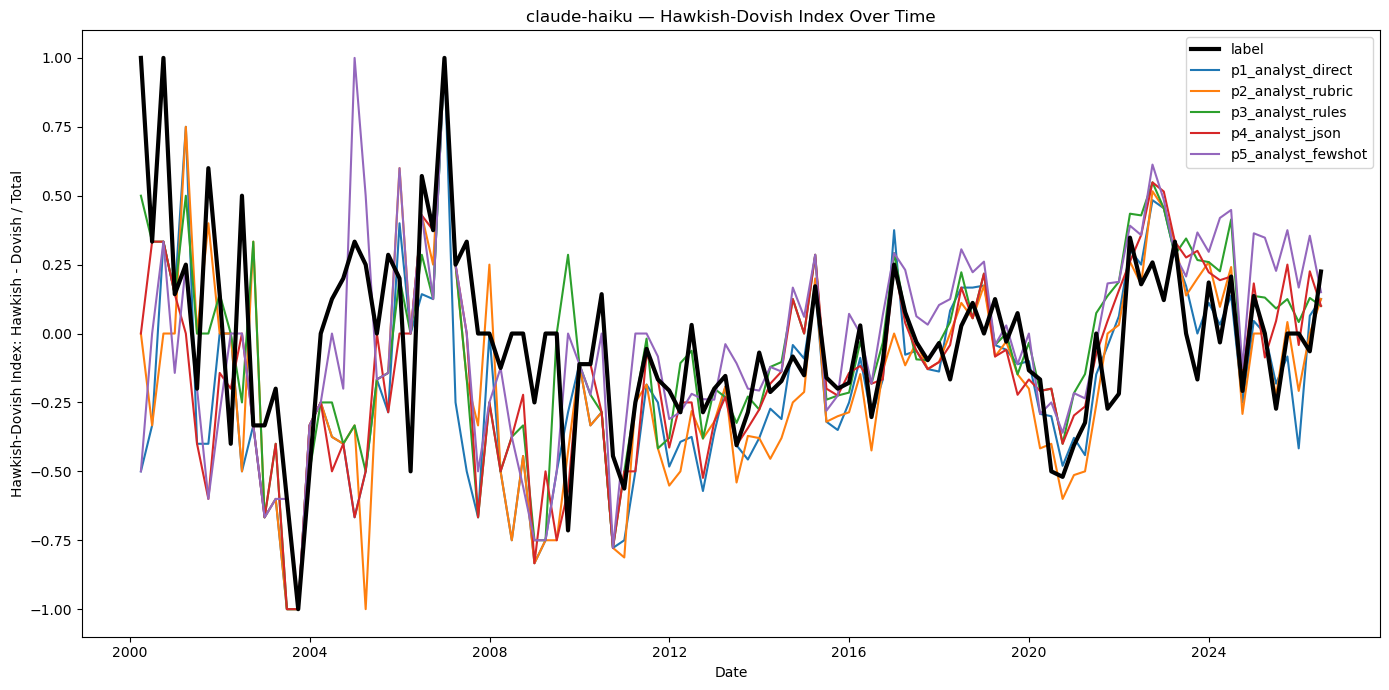

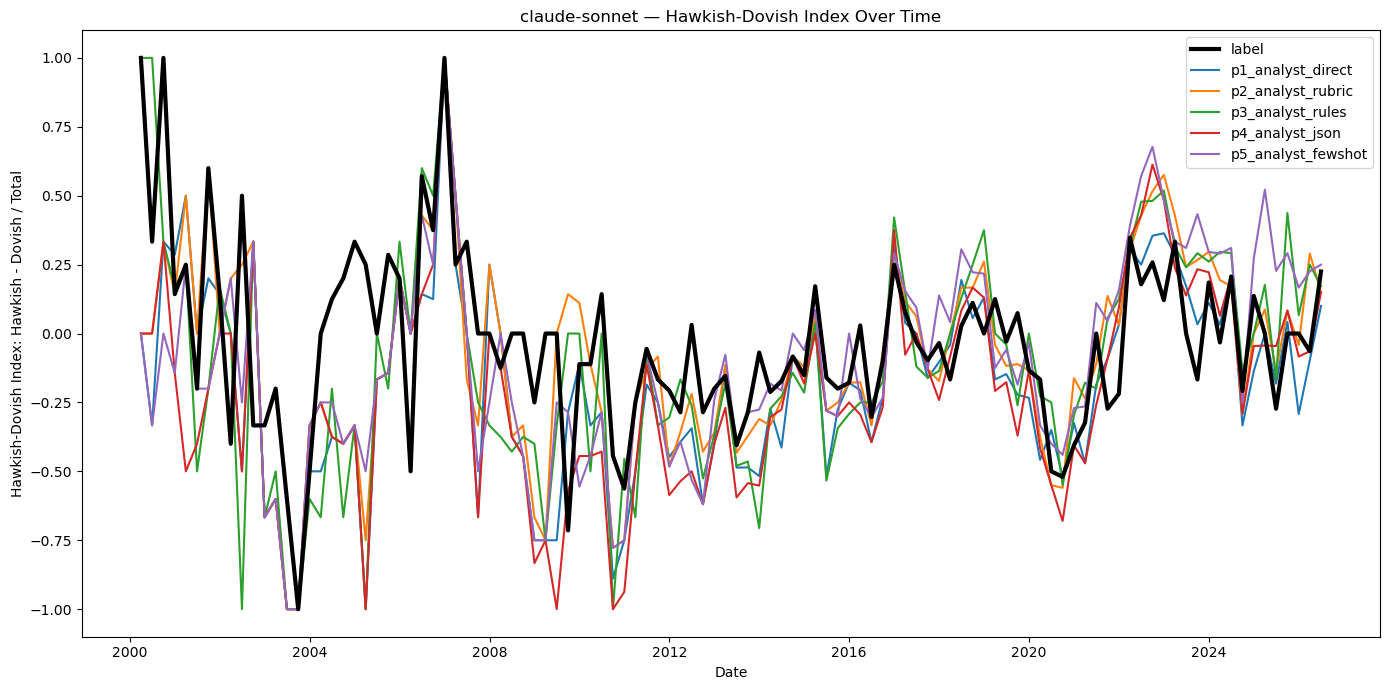

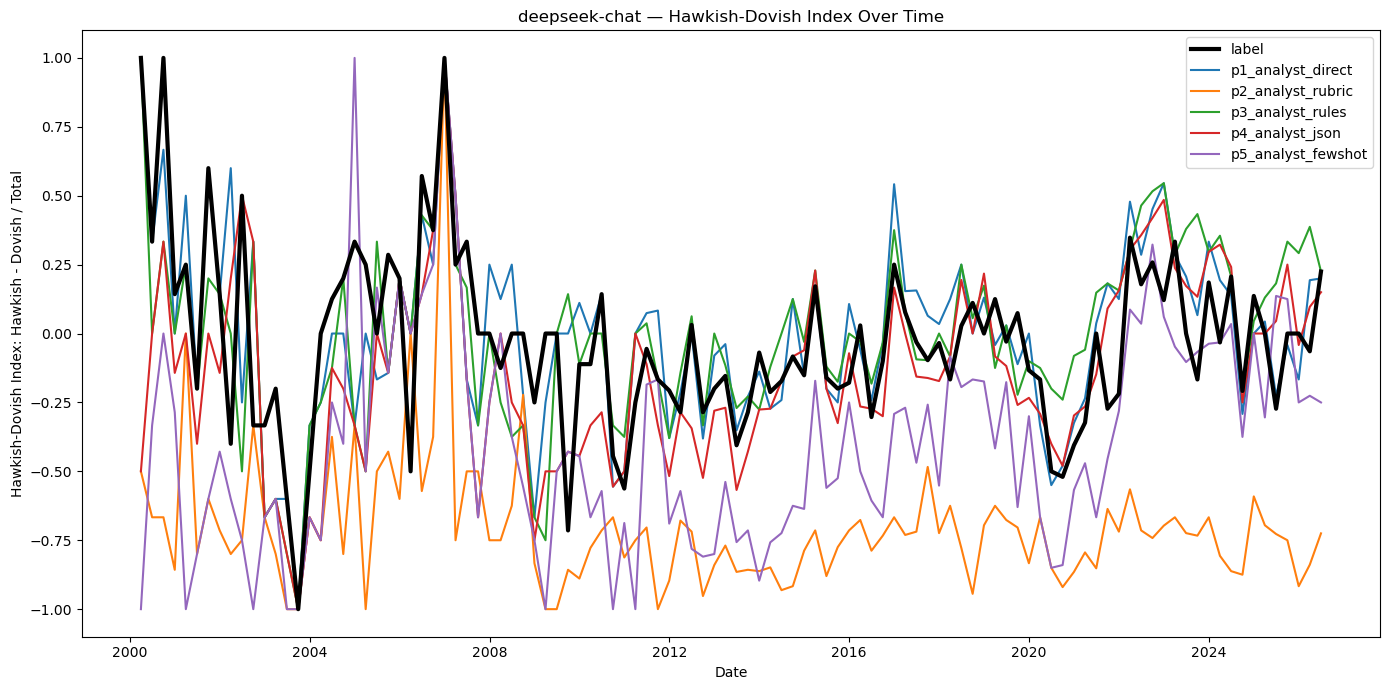

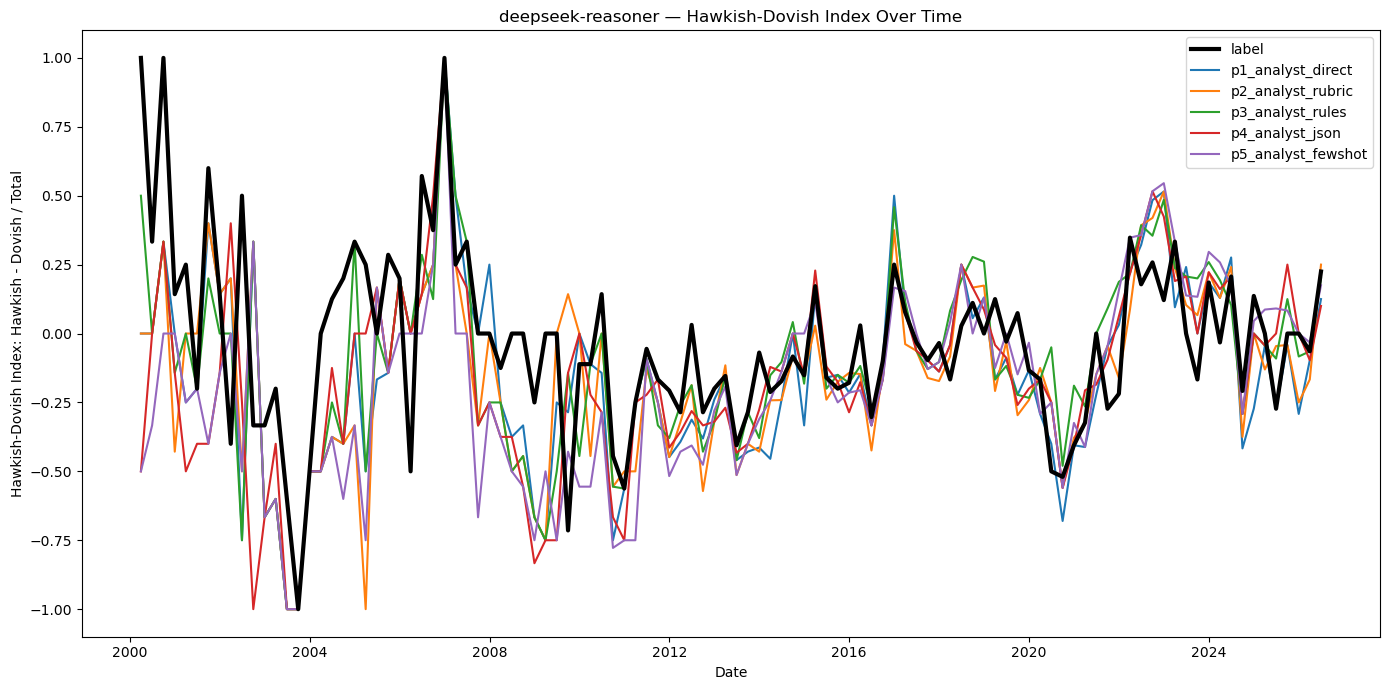

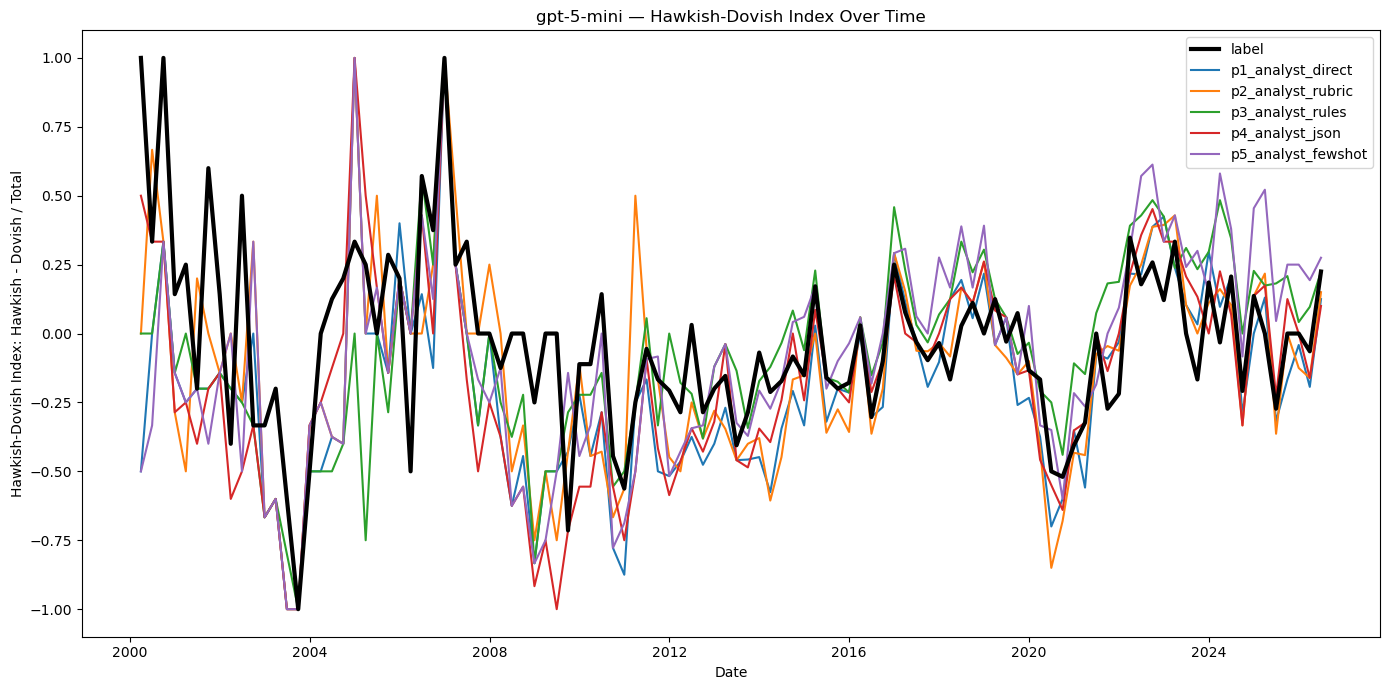

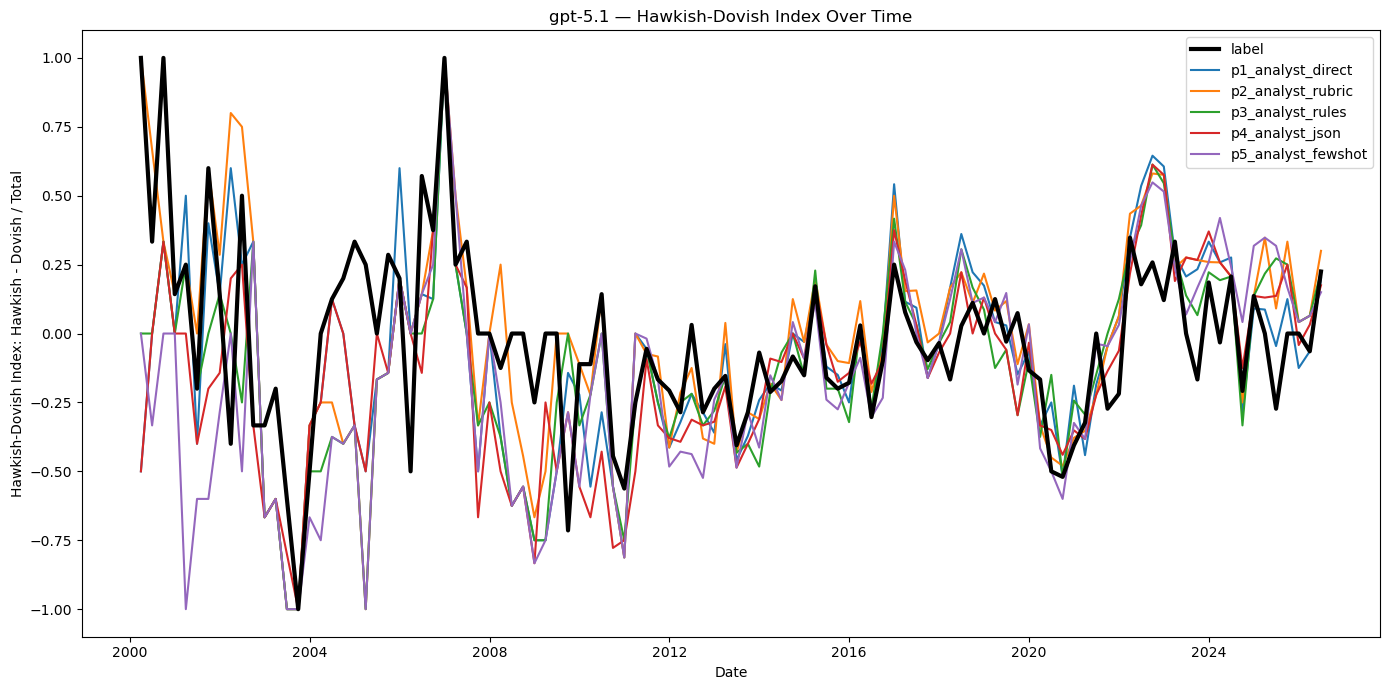

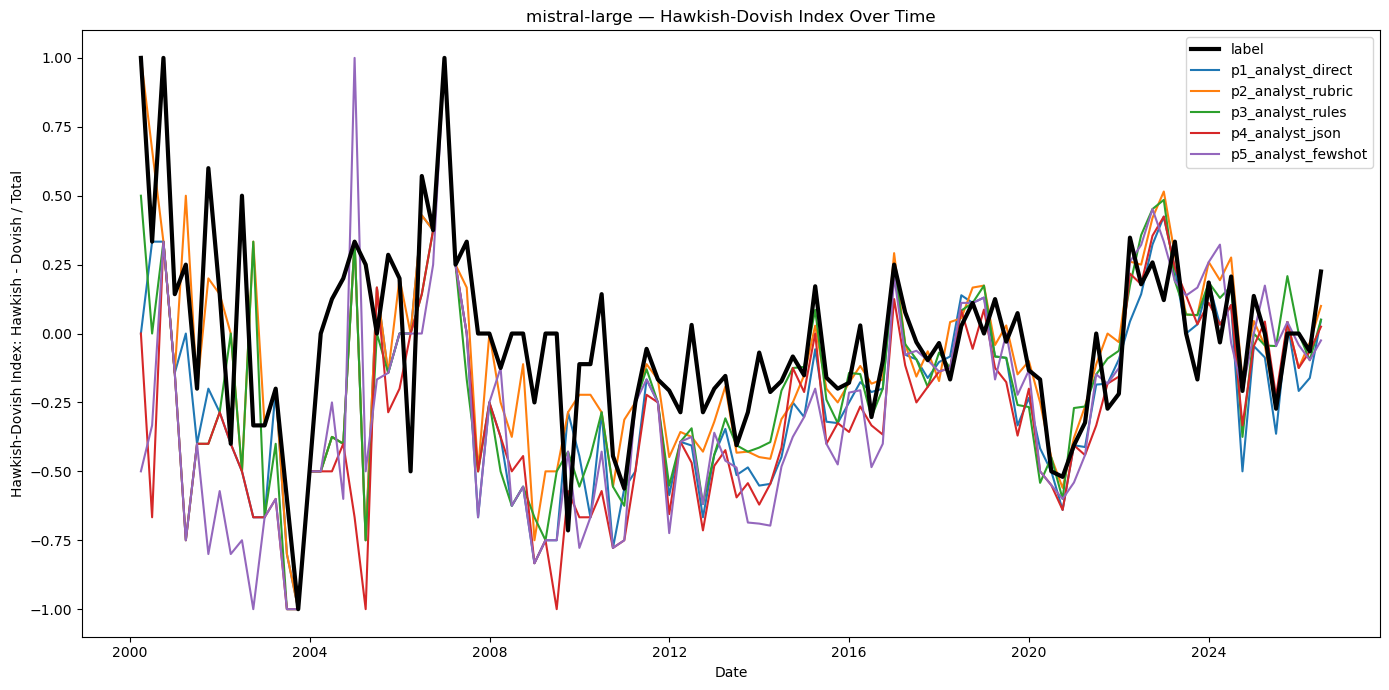

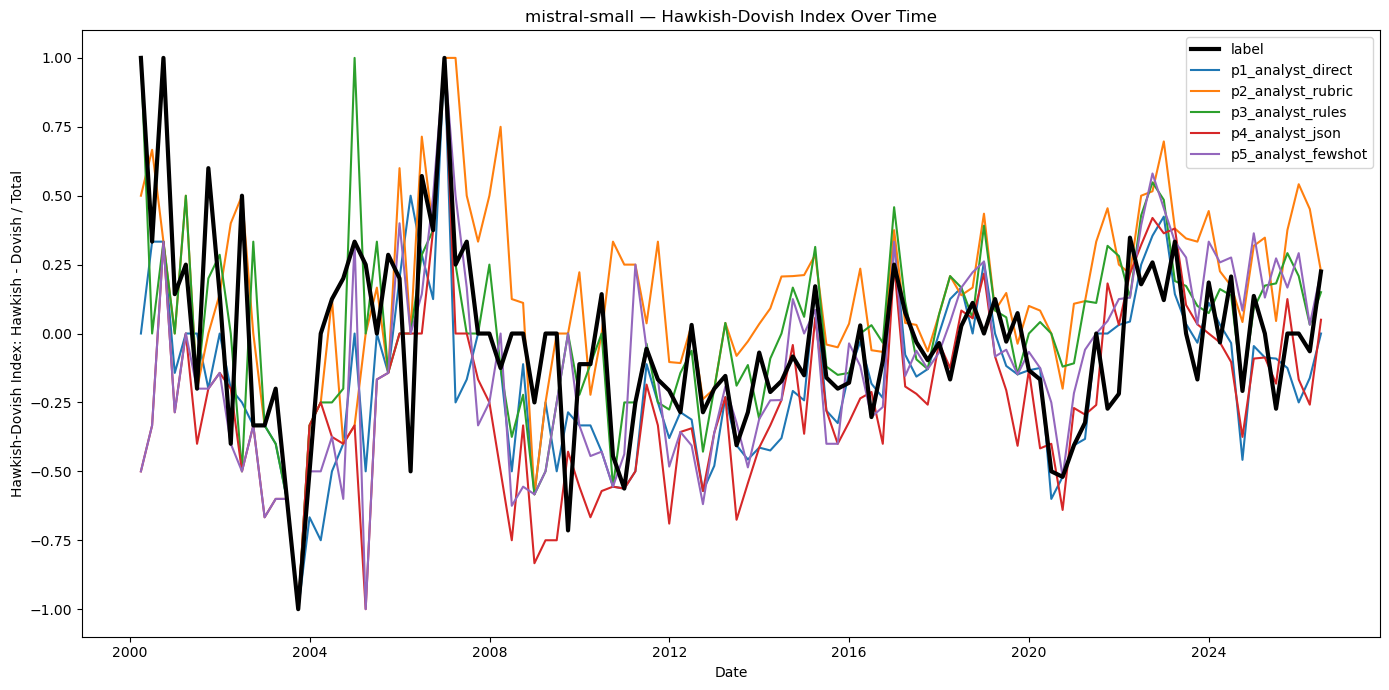

In [9]:
# %% [markdown]
# ### Index Plots per Model Family

# %%
from collections import defaultdict

# Group columns by family
families = defaultdict(list)
for col in model_cols_all:
    family = col.split("__")[0]
    families[family].append(col)

for family, cols in families.items():
    plt.figure(figsize=(14, 7))

    # Always show label as the bold black reference line
    plt.plot(index_df_all.index, index_df_all["label"], label="label",
              linewidth=3, color="black", zorder=3)

    for col in cols:
        prompt_name = col.split("__")[1] if "__" in col else col
        plt.plot(index_df_all.index, index_df_all[col], label=prompt_name,
                  linewidth=1.5, zorder=1)

    plt.title(f"{family} — Hawkish-Dovish Index Over Time")
    plt.xlabel("Date")
    plt.ylabel("Hawkish-Dovish Index: Hawkish - Dovish / Total")
    plt.legend()
    plt.tight_layout()
    plt.show()

Correlation Heatmaps

Not in the speeches file -> excluded from the pooled analysis:
    claude-haiku__p1_analyst_direct
    claude-haiku__p2_analyst_rubric
Columns the speeches file does have for those families: ['claude-haiku__p3_analyst_rules', 'claude-haiku__p4_analyst_json', 'claude-haiku__p5_analyst_fewshot'] 

           count        min        max
source                                
speech       951 1996-01-01 2026-01-01
statement   1998 2000-02-02 2026-06-17


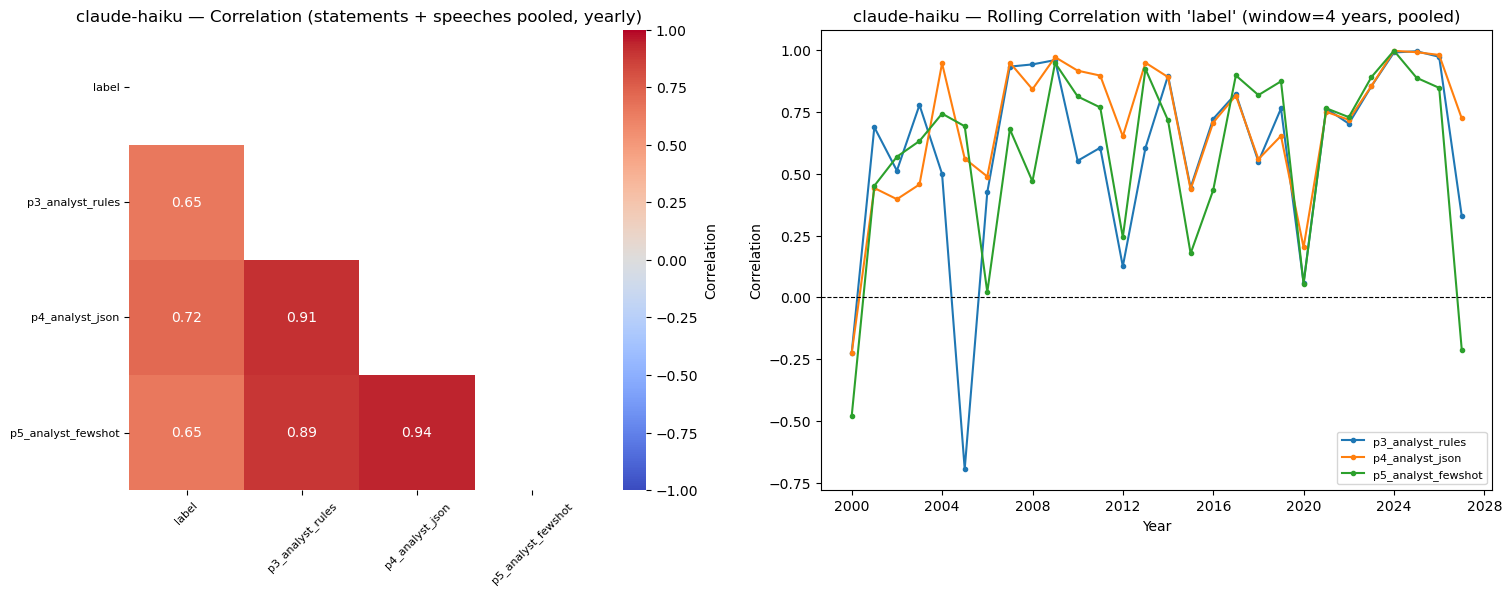

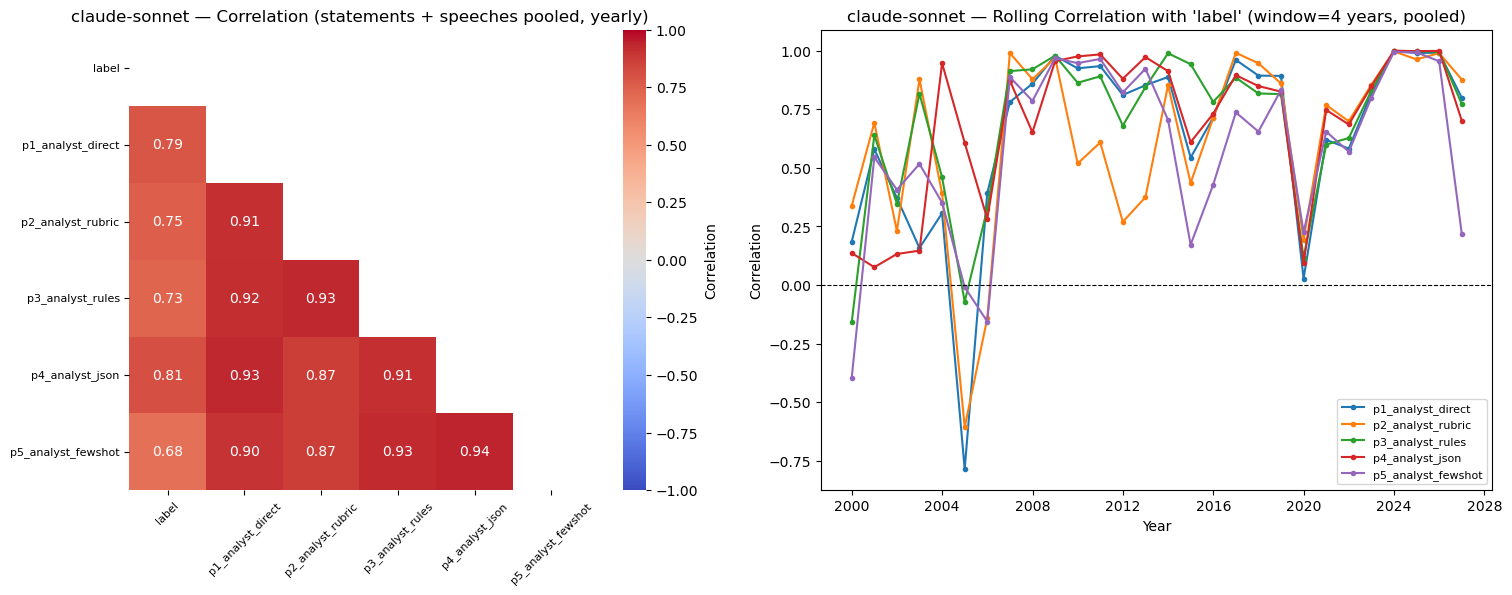

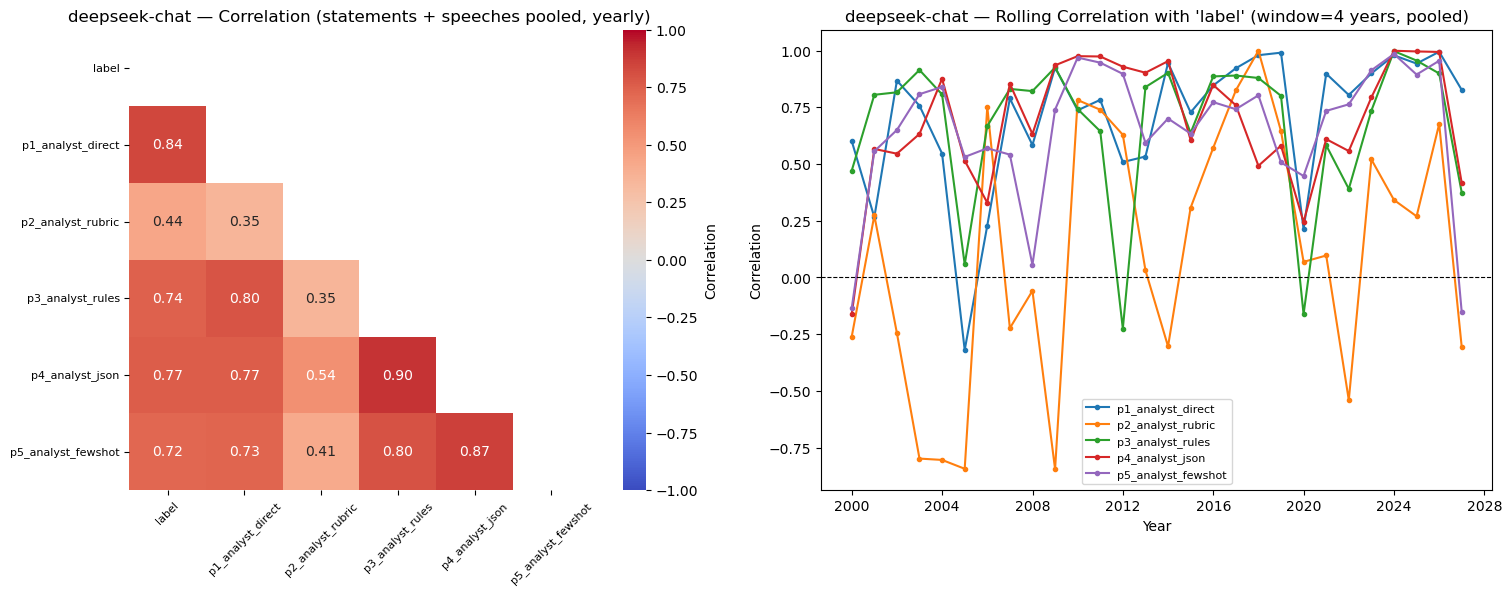

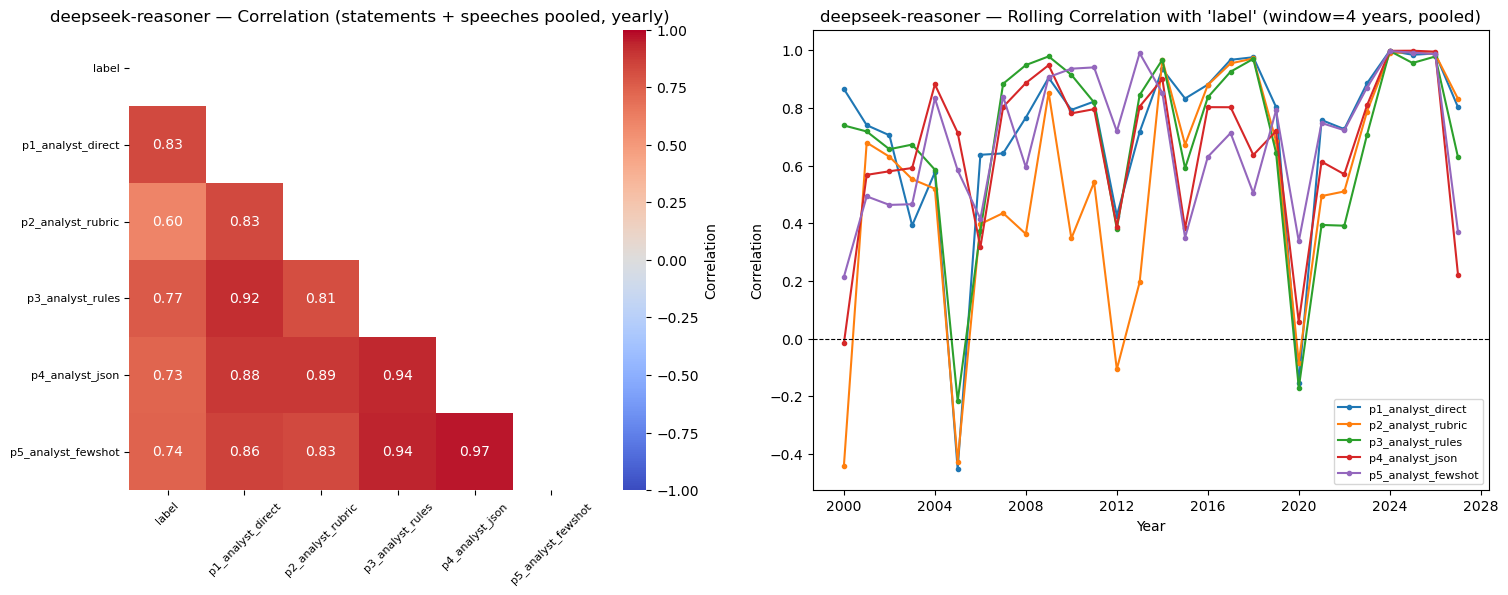

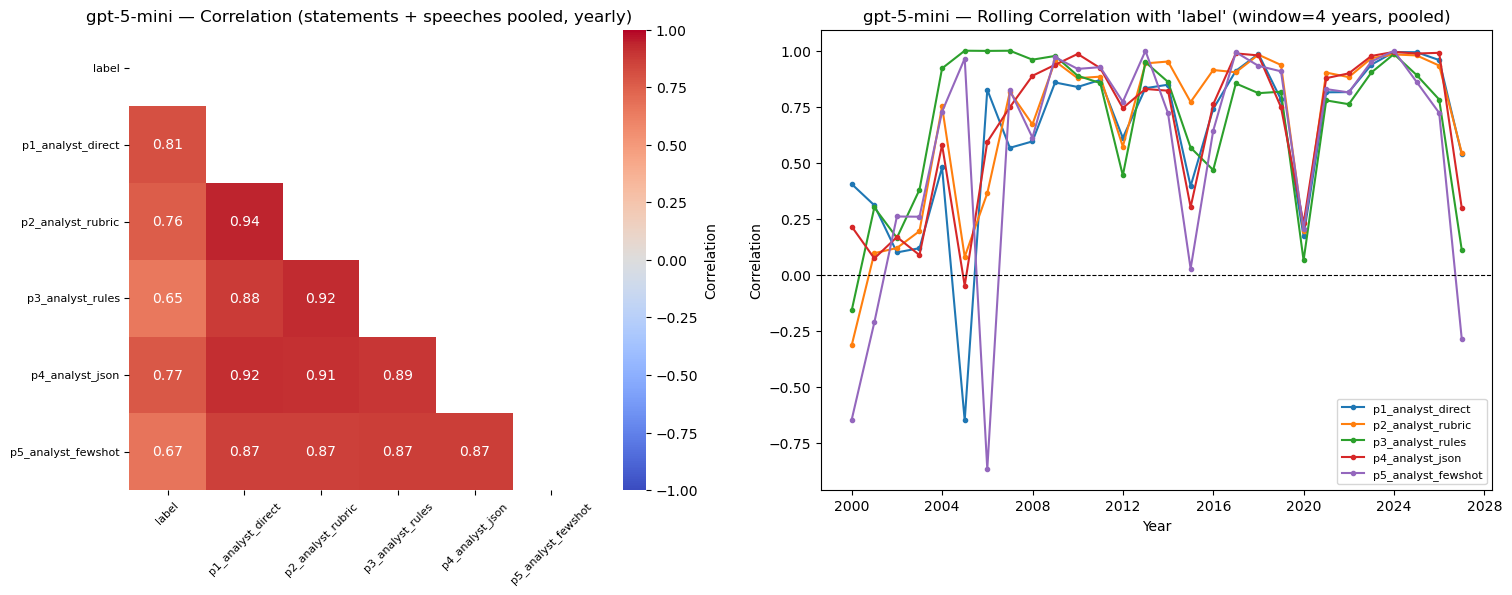

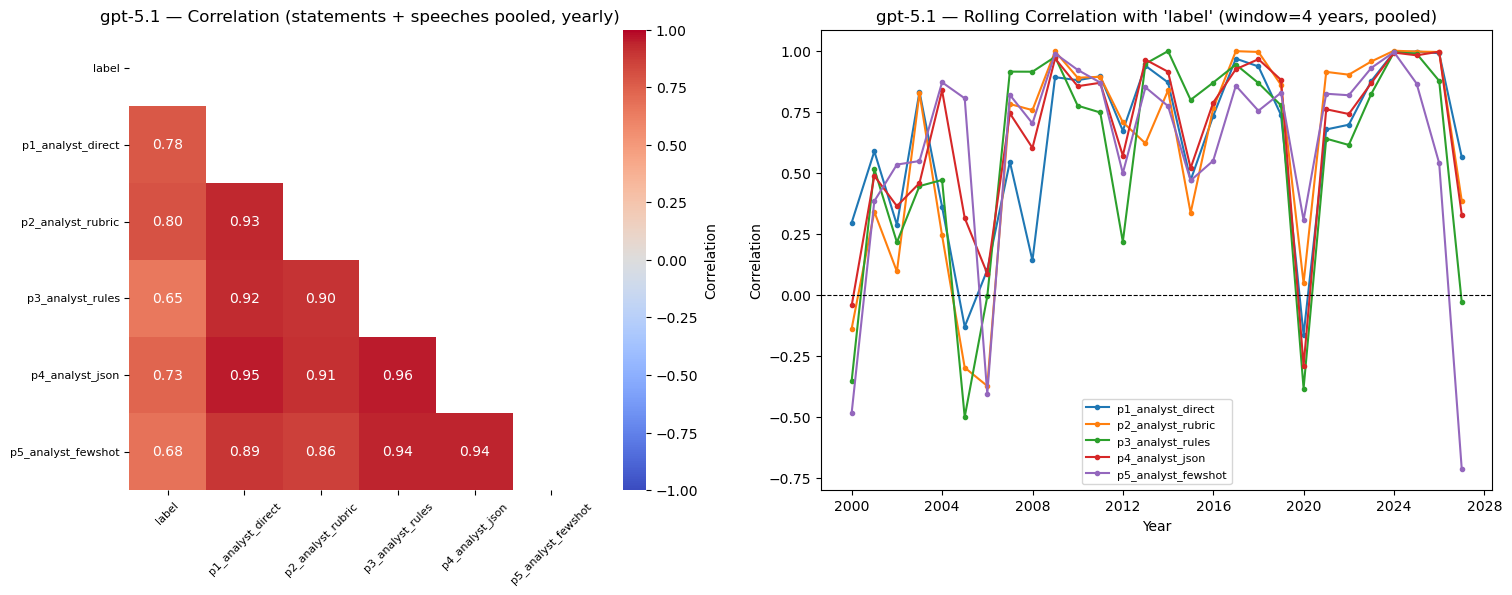

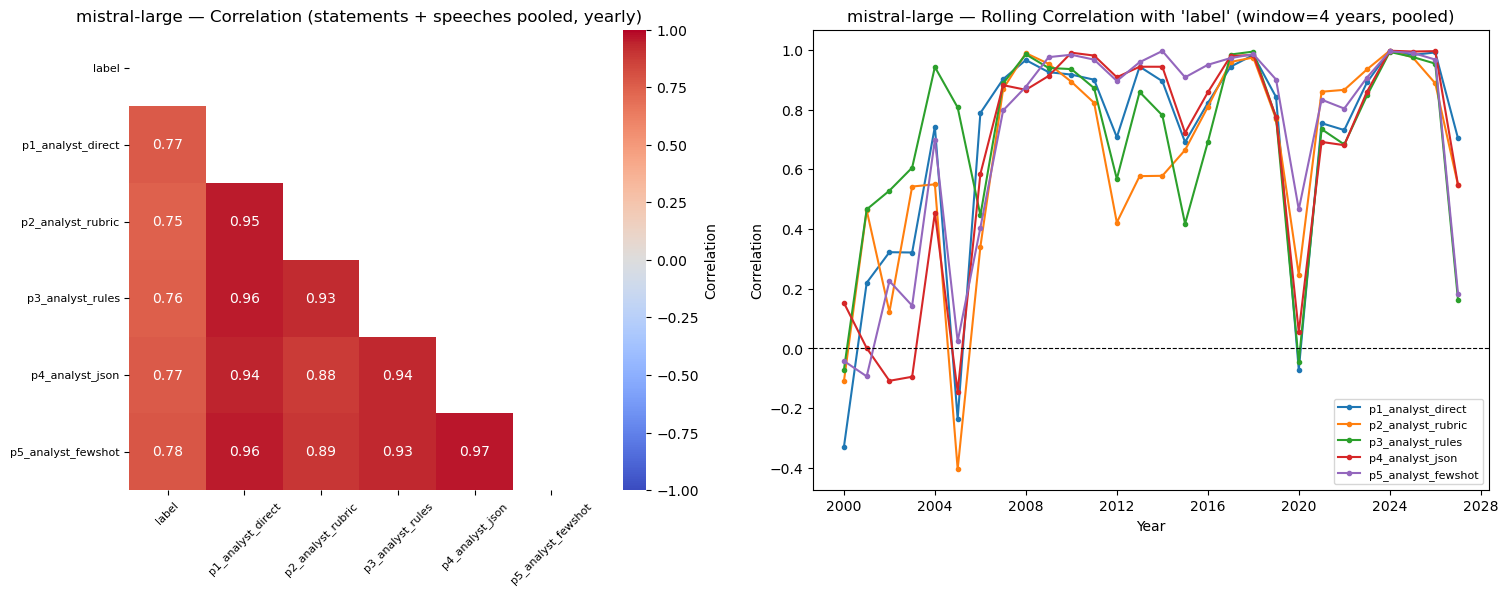

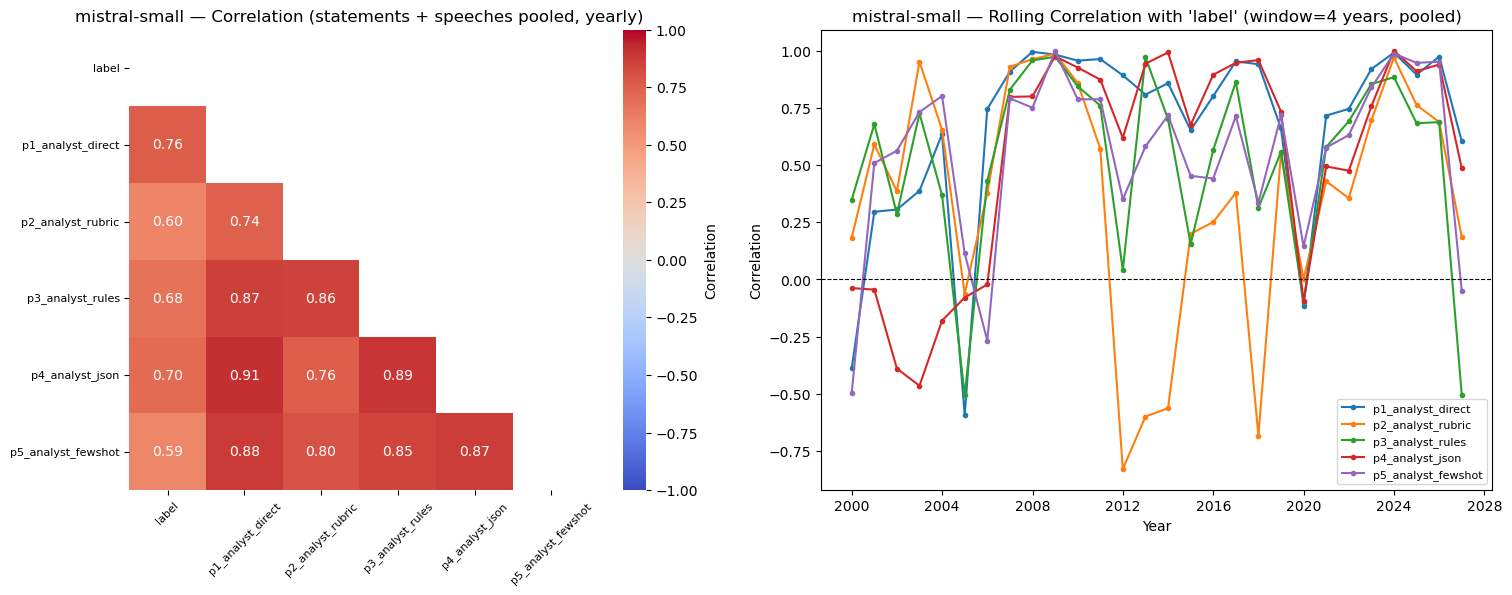

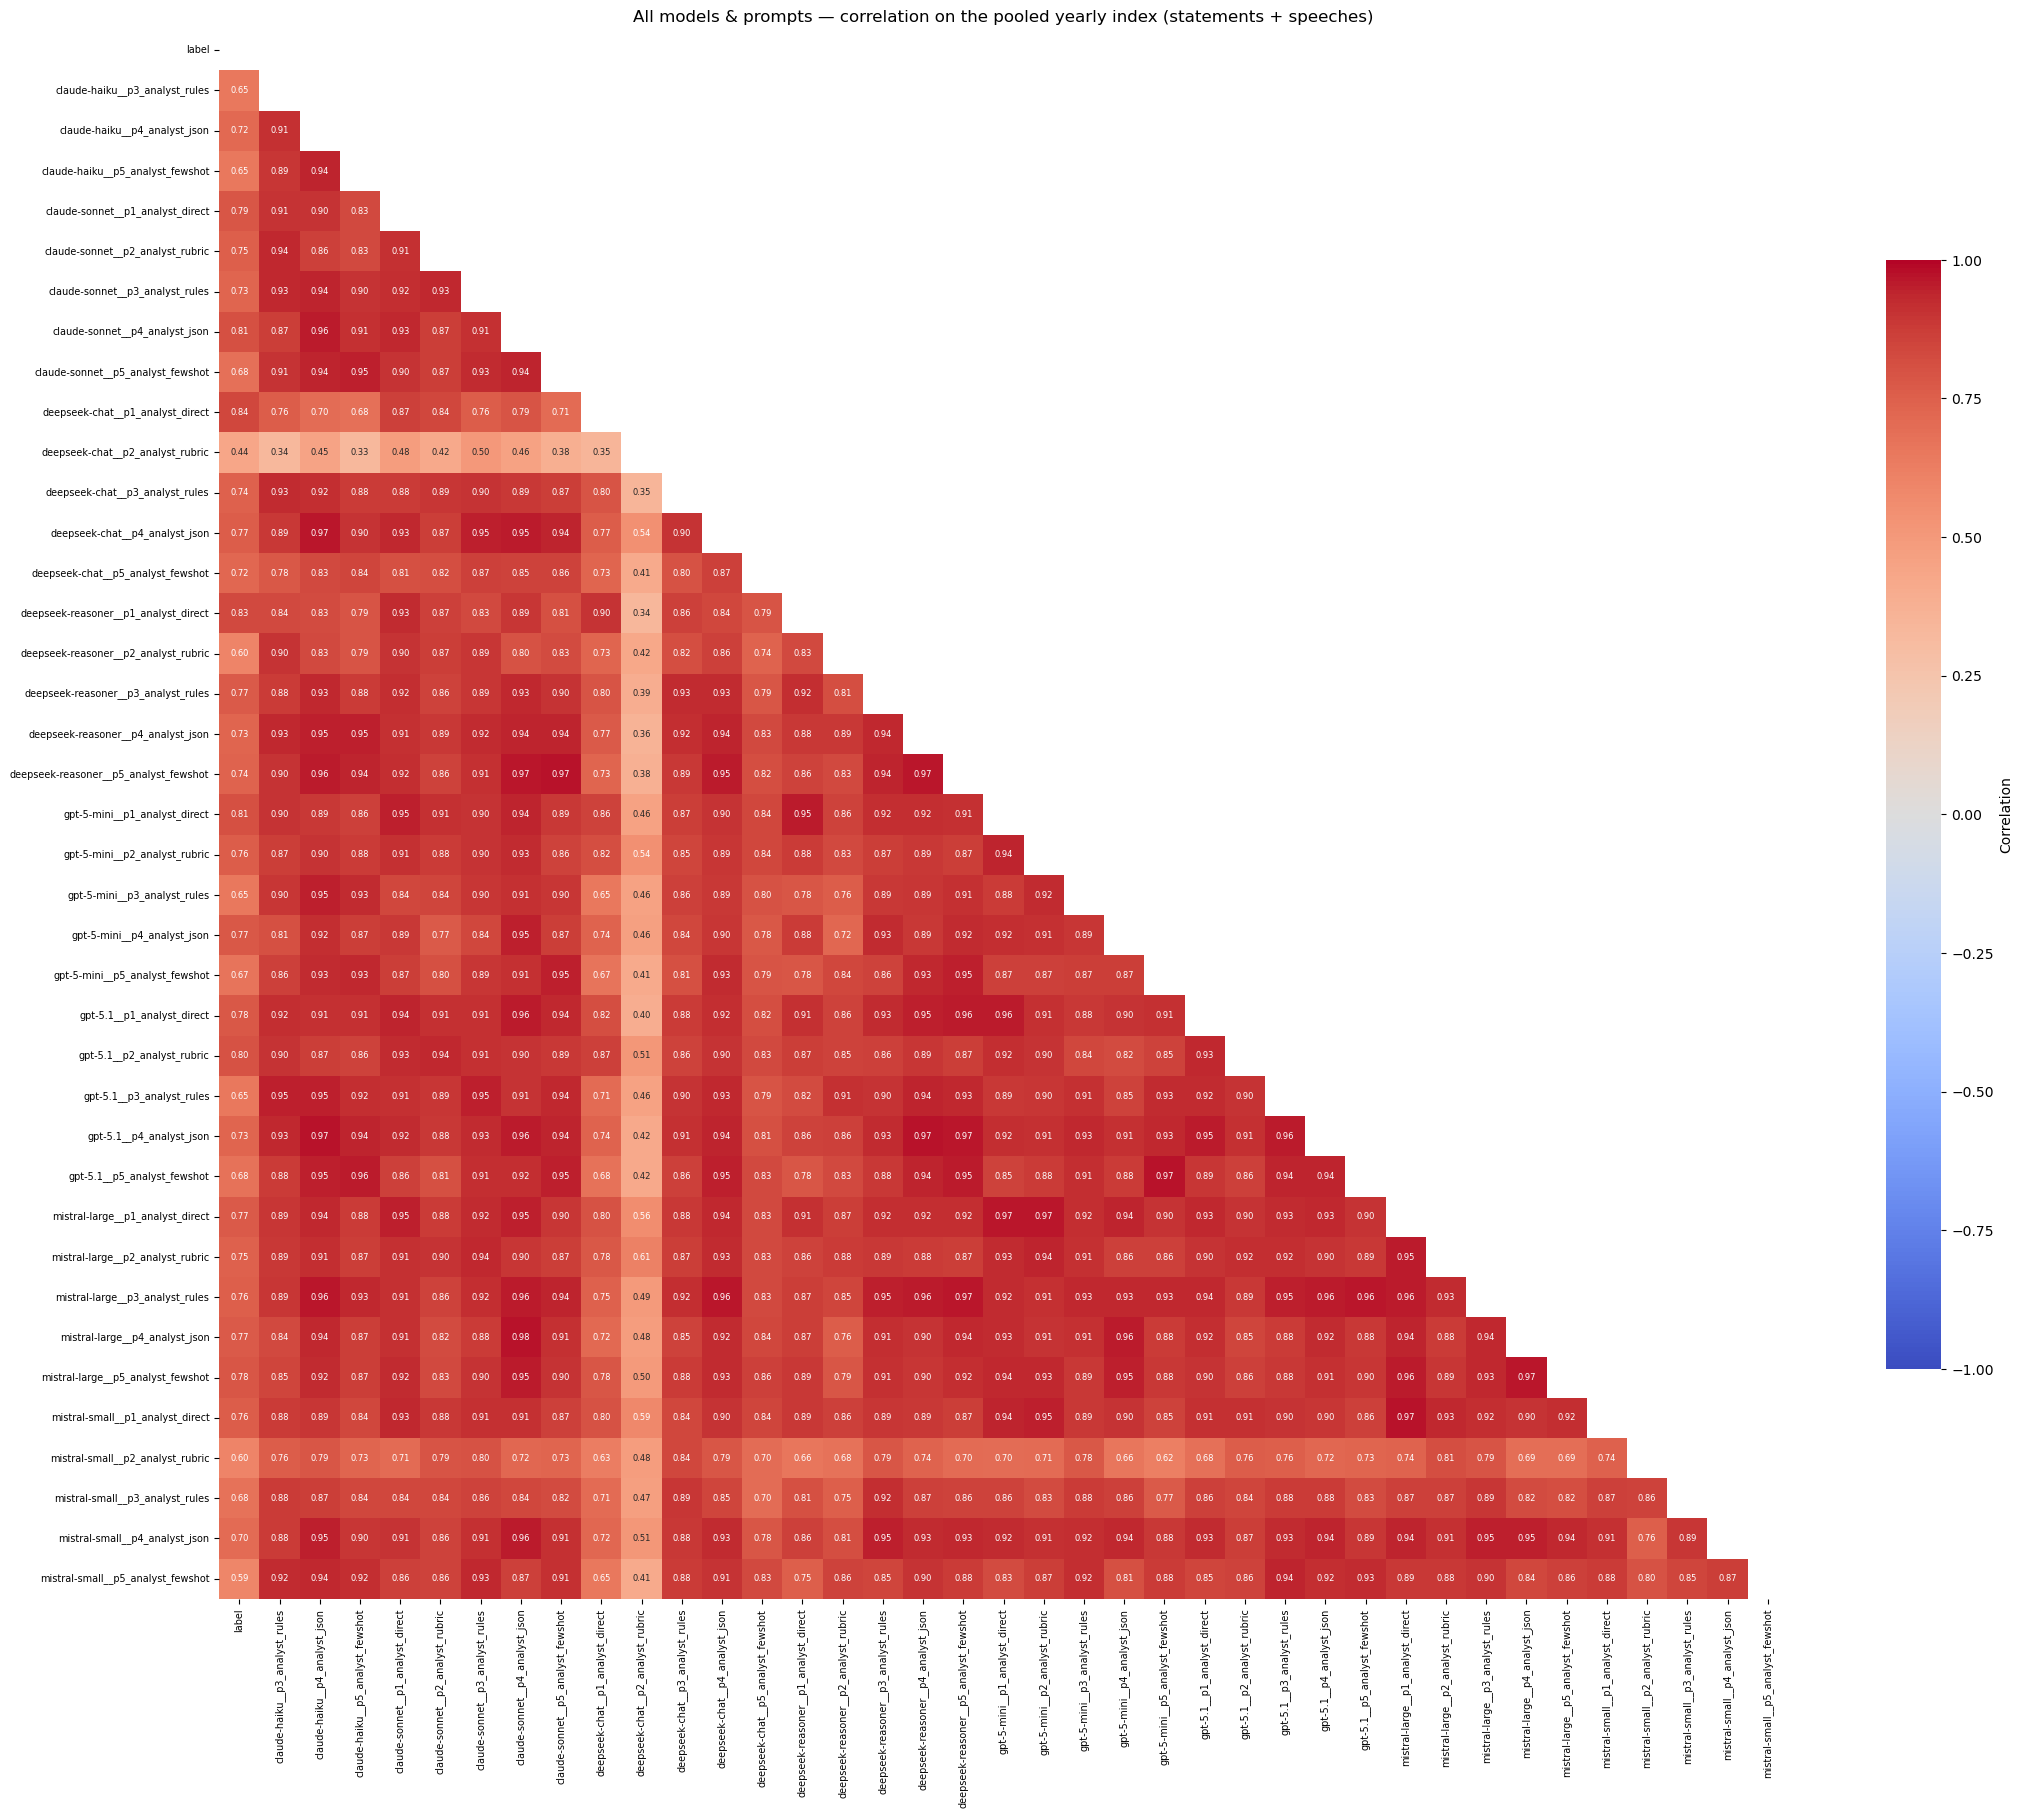

In [20]:
# %% [markdown]
# ### Pooled YEARLY index — statements + speeches in one sample (Fed)
#
# The Fed speeches are only dated by year, so the pooled index is built at
# **yearly** frequency: the statement / press-conference sentences (full dates)
# are collapsed into calendar years by the yearly grouper, and each speech
# year is parsed as that same calendar year. Both corpora then fall into
# identical yearly bins and are pooled *before* the index is computed.
#
# Relies on `All_Model_Analysis_df`, `LLM_Extension_Excel_Speeches`,
# `model_cols_all` and `build_index` already existing in the kernel.

# %%
def parse_dates(s):
    """Parse a date column that holds full dates OR bare years (2015, '2015', 2015.0).
    Bare years must not go through pd.to_datetime directly: to_datetime(2015)
    would be read as 2015 nanoseconds after 1970."""
    s = pd.Series(s)
    if pd.api.types.is_datetime64_any_dtype(s):
        return s
    num = pd.to_numeric(s, errors="coerce")
    is_year = num.between(1900, 2100)
    real_dates = pd.to_datetime(s.where(~is_year), errors="coerce")
    year_dates = pd.to_datetime(num.where(is_year).round().astype("Int64").astype(str),
                                format="%Y", errors="coerce")
    return real_dates.fillna(year_dates)


# --- Speeches: sentence-level frame with the same columns as the statements one ---
speech_date_col = "date" if "date" in LLM_Extension_Excel_Speeches.columns else "year"
assert "label" in LLM_Extension_Excel_Speeches.columns, "speeches file has no 'label' column"

# Model+prompt combos that were never run on the speeches can't be pooled:
# a statements-only index would not be comparable with the pooled `label`
# index, so they are dropped from this section (and reported).
missing = [c for c in model_cols_all if c not in LLM_Extension_Excel_Speeches.columns]
model_cols_pooled = [c for c in model_cols_all if c not in missing]
if missing:
    print("Not in the speeches file -> excluded from the pooled analysis:")
    for c in missing:
        print("   ", c)
    near = [c for c in LLM_Extension_Excel_Speeches.columns
            if any(c.startswith(m.split("__")[0]) for m in missing)]
    print("Columns the speeches file does have for those families:", near, "\n")

Speeches_df = (LLM_Extension_Excel_Speeches[[speech_date_col, "label"] + model_cols_pooled]
               .rename(columns={speech_date_col: "date"})
               .copy())
Speeches_df["date"] = parse_dates(Speeches_df["date"])

# --- Statements / press conferences ---
Statements_df = All_Model_Analysis_df[["date", "label"] + model_cols_pooled].copy()
Statements_df["date"] = parse_dates(Statements_df["date"])

# --- Pool ---
pooled_df = pd.concat(
    [Statements_df.assign(source="statement"),
     Speeches_df.assign(source="speech")],
    ignore_index=True,
).dropna(subset=["date"])

# Sanity check: both corpora should span comparable years
print(pooled_df.groupby("source")["date"].agg(["count", "min", "max"]))

# Yearly index on the pooled sample. freq="YE" collapses the dated statement
# sentences into calendar years, matching the speeches' year-only dates.
index_df_pooled = pd.DataFrame(
    {col: build_index(pooled_df, freq="YE", label_col=col)
     for col in ["label"] + model_cols_pooled}
)
index_df_pooled.head(10)

# %% [markdown]
# ### Correlation per Model Family — pooled statements + speeches (yearly)

# %%
from collections import defaultdict

families = defaultdict(list)
for col in model_cols_pooled:
    families[col.split("__")[0]].append(col)

window = 4  # YEARS now, not quarters

for family, cols in families.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Subset to this family's columns + label, short names for the ticks
    family_df = index_df_pooled[["label"] + cols].copy()
    family_df.columns = ["label"] + [c.split("__")[1] for c in cols]

    # --- Left: masked correlation heatmap ---
    corr_matrix = family_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1, ax=axes[0], square=True,
                mask=mask, cbar_kws={"label": "Correlation"})
    axes[0].set_title(f"{family} — Correlation (statements + speeches pooled, yearly)")
    axes[0].tick_params(axis="x", labelsize=8, rotation=45)
    axes[0].tick_params(axis="y", labelsize=8, rotation=0)

    # --- Right: rolling correlation with label ---
    for col in cols:
        prompt_name = col.split("__")[1]
        rolling_corr = index_df_pooled[col].rolling(window).corr(index_df_pooled["label"])
        axes[1].plot(index_df_pooled.index, rolling_corr,
                     label=prompt_name, linewidth=1.5, marker="o", markersize=3)

    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title(f"{family} — Rolling Correlation with 'label' "
                      f"(window={window} years, pooled)")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Correlation")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# %% [markdown]
# #### Every model + prompt in one matrix (pooled yearly index)

# %%
corr_all = index_df_pooled[["label"] + model_cols_pooled].corr()
mask = np.triu(np.ones_like(corr_all, dtype=bool))

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(corr_all, annot=True, fmt=".2f", annot_kws={"size": 6},
            cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            mask=mask, ax=ax, cbar_kws={"label": "Correlation", "shrink": 0.6})
ax.set_title("All models & prompts — correlation on the pooled yearly index (statements + speeches)")
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=7, rotation=0)
plt.tight_layout()
plt.show()

Confusion Matrices

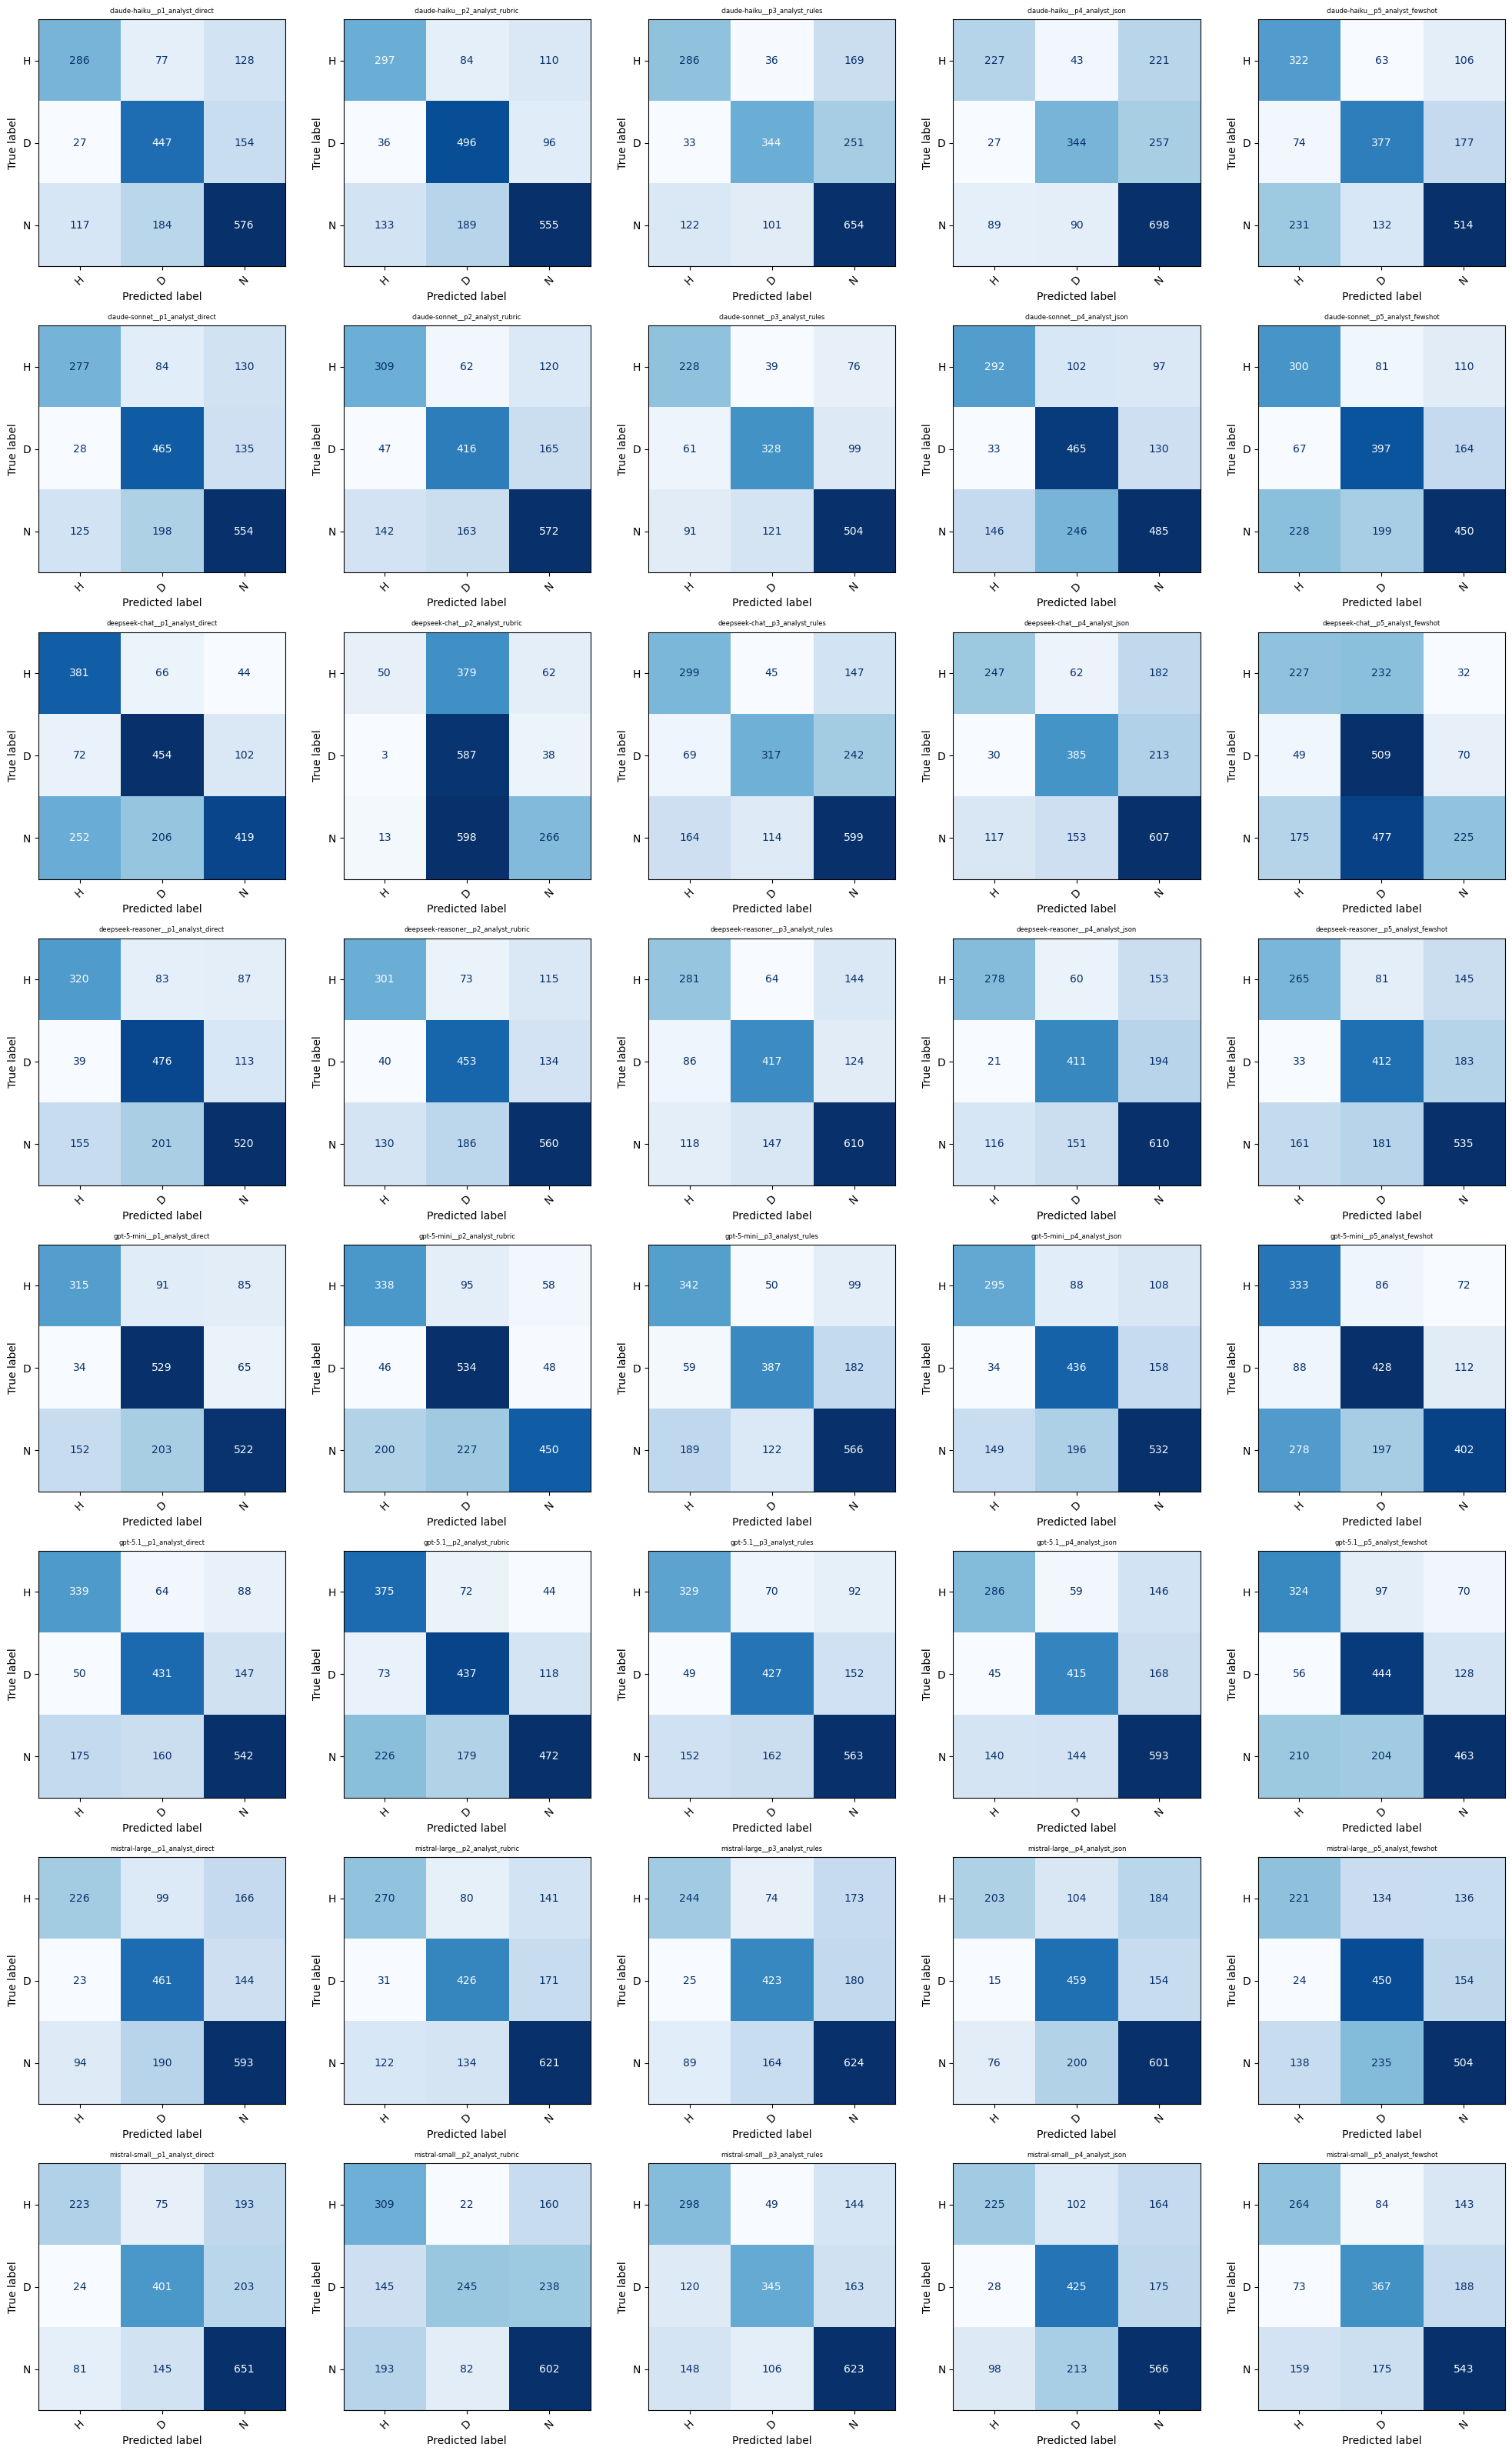

In [11]:
# %% [markdown]
# ### Confusion Matrices — All Models

# %%
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

valid_categories = ["H", "D", "N"]

# Base eval set: keep only rows where ground truth is one of H/D/N
eval_base = All_Model_Analysis_df[All_Model_Analysis_df["label"].isin(valid_categories)]

n_models = len(model_cols_all)
n_cols = 5
n_rows = -(-n_models // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(model_cols_all):
    # Keep only rows where this model's prediction is also H/D/N
    pair_df = eval_base[eval_base[col].isin(valid_categories)]

    cm = confusion_matrix(pair_df["label"], pair_df[col], labels=valid_categories)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=valid_categories)
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues", xticks_rotation=45)
    axes[i].set_title(col, fontsize=6)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Best Performing Model

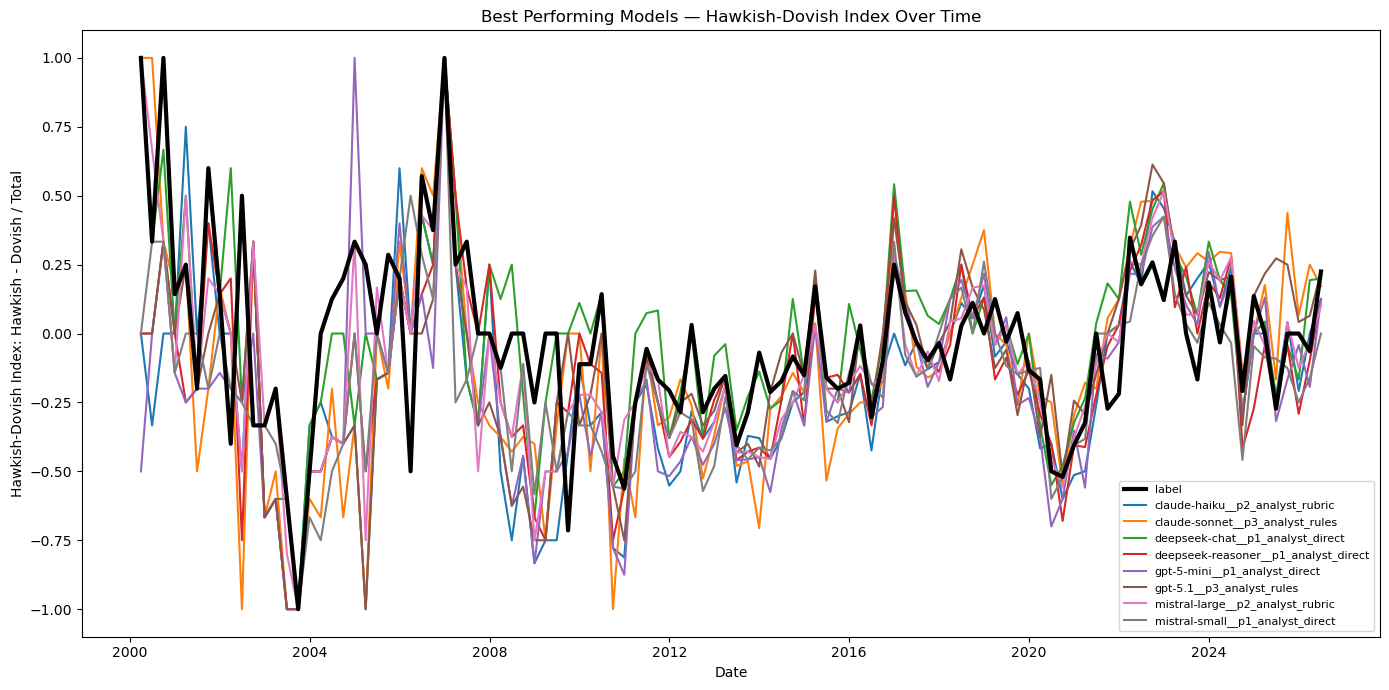

In [12]:
# Best Performing by Model Class Time Series Plots
Best_performing_models_cols=    ['claude-haiku__p2_analyst_rubric', 
                                 'claude-sonnet__p3_analyst_rules', 
                                 'deepseek-chat__p1_analyst_direct',
                                 'deepseek-reasoner__p1_analyst_direct',
                                 'gpt-5-mini__p1_analyst_direct',
                                 'gpt-5.1__p3_analyst_rules',
                                 'mistral-large__p2_analyst_rubric',
                                 'mistral-small__p1_analyst_direct']


plt.figure(figsize=(14, 7))

plt.plot(index_df_all.index, index_df_all["label"], label="label",
          linewidth=3, color="black", zorder=3)

for col in Best_performing_models_cols:
    plt.plot(index_df_all.index, index_df_all[col], label=col,
              linewidth=1.5, zorder=1)

plt.title("Best Performing Models — Hawkish-Dovish Index Over Time")
plt.xlabel("Date")
plt.ylabel("Hawkish-Dovish Index: Hawkish - Dovish / Total")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()




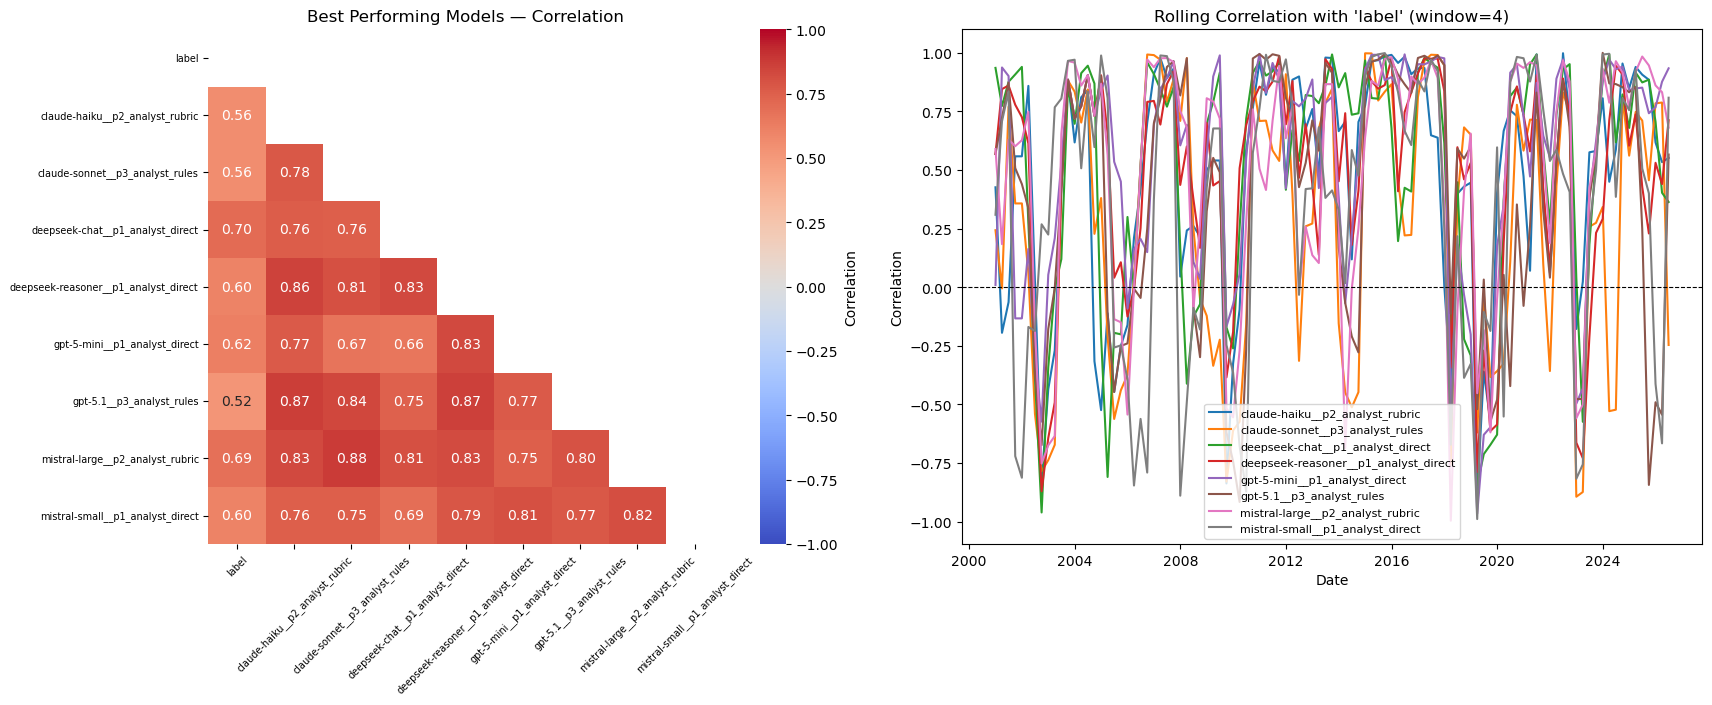

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

best_df = index_df_all[["label"] + Best_performing_models_cols]

# --- Left: masked correlation heatmap ---
corr_matrix = best_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=axes[0], square=True,
            mask=mask, cbar_kws={"label": "Correlation"})
axes[0].set_title("Best Performing Models — Correlation")
axes[0].tick_params(axis='x', labelsize=7, rotation=45)
axes[0].tick_params(axis='y', labelsize=7)

# --- Right: rolling correlation with label ---
window = 4
for col in Best_performing_models_cols:
    rolling_corr = index_df_all[col].rolling(window).corr(index_df_all["label"])
    axes[1].plot(index_df_all.index, rolling_corr, label=col, linewidth=1.5)

axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Rolling Correlation with 'label' (window={window})")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Correlation")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

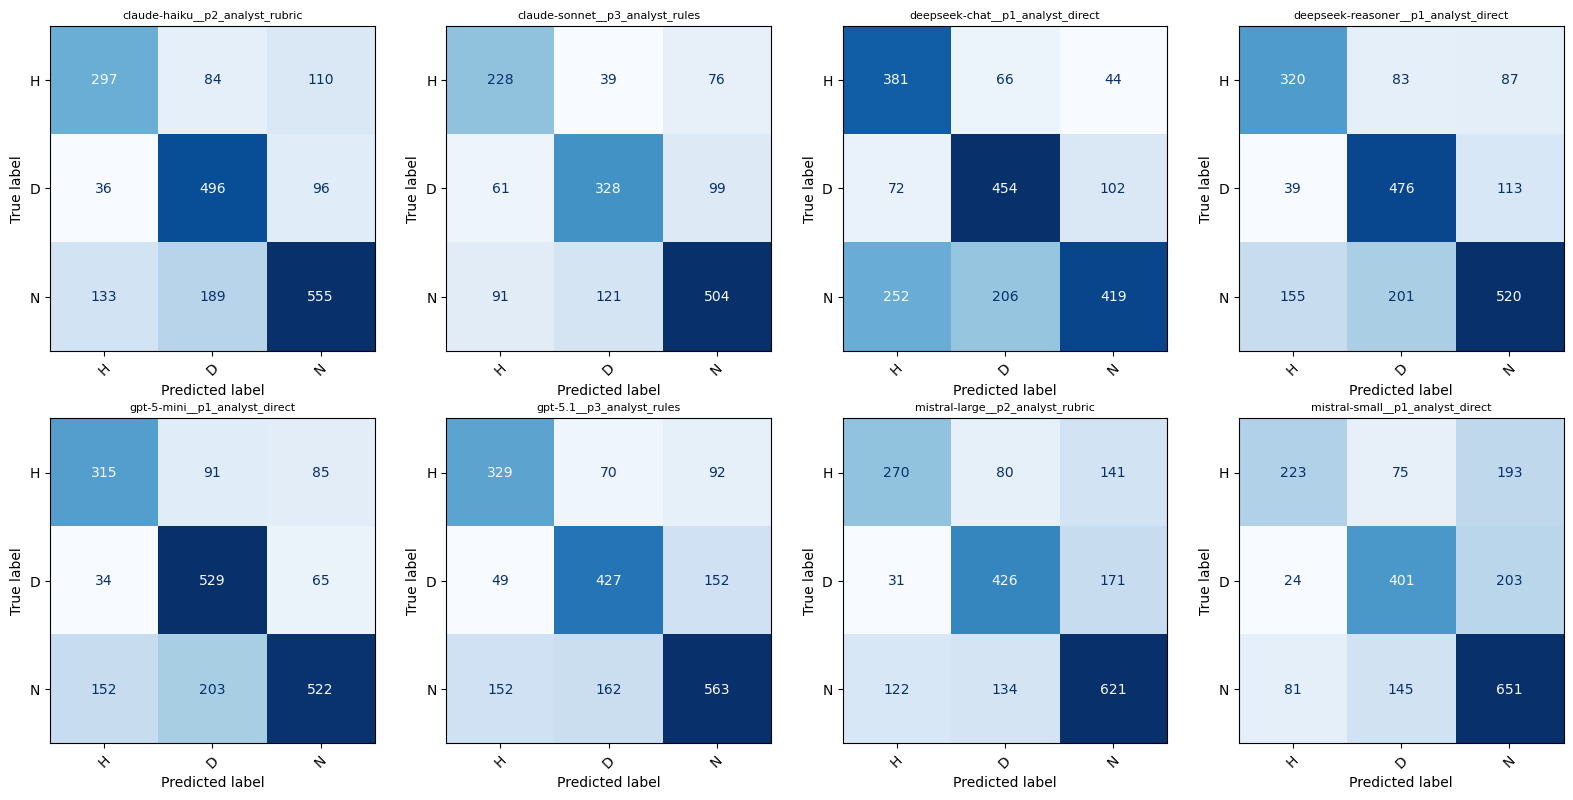

In [14]:
valid_categories = ["H", "D", "N"]

eval_base = All_Model_Analysis_df[All_Model_Analysis_df["label"].isin(valid_categories)]

n_models = len(Best_performing_models_cols)
n_cols = 4
n_rows = -(-n_models // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(Best_performing_models_cols):
    pair_df = eval_base[eval_base[col].isin(valid_categories)]

    cm = confusion_matrix(pair_df["label"], pair_df[col], labels=valid_categories)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=valid_categories)
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues", xticks_rotation=45)
    axes[i].set_title(col, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

BEST Performing Prompts and associtate dataframe

In [15]:
Best_Performance_Comparison_df = LLM_Extension_Excel_data[
    ['date', 'sentence', 'label'] + Best_performing_models_cols
].copy()

Best_Performance_Comparison_df["date"] = pd.to_datetime(
    Best_Performance_Comparison_df["date"], errors="coerce"
)

Best_Performance_Comparison_df.head(20)

,date,sentence,label,claude-haiku__p2_analyst_rubric,claude-sonnet__p3_analyst_rules,deepseek-chat__p1_analyst_direct,deepseek-reasoner__p1_analyst_direct,gpt-5-mini__p1_analyst_direct,gpt-5.1__p3_analyst_rules,mistral-large__p2_analyst_rubric,mistral-small__p1_analyst_direct
0,2000-02-02,"In these circumstances, and against the backgr...",H,H,H,H,H,N,H,H,N
1,2000-03-21,Although core measures of prices are rising sl...,H,D,NaN,H,D,D,D,H,N
2,2000-05-16,Against the background of its long-term goals ...,H,H,H,H,H,H,H,H,H
3,2000-05-16,Recent data suggest that the expansion of aggr...,N,D,NaN,H,N,N,N,N,N
4,2000-06-28,The data also have indicated that more rapid a...,N,D,NaN,D,D,D,D,H,N
5,2000-08-22,Recent data have indicated that the expansion ...,H,D,N,H,N,N,N,N,N
6,2000-08-22,"Moreover, the increase in energy prices, thoug...",H,H,H,H,H,H,H,H,H
7,2000-08-22,The Federal Open Market Committee at its meeti...,H,N,N,N,N,N,N,N,N
8,2000-10-03,"Nonetheless, to date the easing of demand pres...",H,H,H,H,H,N,H,N,N
9,2000-10-03,"The Committee, accordingly, continues to see a...",D,H,H,H,H,H,H,H,H


In [16]:
Best_Performance_Comparison_df.to_csv("best_performing_predictions.csv", index=False)

In [17]:
# %% [markdown]
# ### Divergence from the hand-annotated index — worst periods per model & prompt
#
# Paste these cells after the "Building the indicie" section: they rely on
# `index_df_all`, `model_cols_all`, `families` and `Best_performing_models_cols`
# already existing in the kernel.
#
# Divergence is measured on the quarterly Hawkish–Dovish index as
# `model_index - label_index`, so:
# **positive = the model reads the quarter as MORE hawkish than the annotators,
# negative = MORE dovish.**

# %%
# Signed and absolute divergence, quarter by quarter
signed_div = index_df_all[model_cols_all].sub(index_df_all["label"], axis=0)
abs_div = signed_div.abs()

# Prettier quarter labels (2008Q4 instead of 2008-12-31)
signed_div.index = signed_div.index.to_period("Q")
abs_div.index = abs_div.index.to_period("Q")

abs_div.round(2).head()

# %% [markdown]
# #### Table 1 — worst-diverging quarters for every model + prompt
# One row per model+prompt, ranked by its single worst quarter. The signed value
# in parentheses gives the direction of the miss (+ too hawkish, − too dovish).

# %%
K = 3  # how many worst quarters to list per model+prompt

def worst_periods(col, k=K):
    top = abs_div[col].nlargest(k)
    row = {}
    for rank, (period, magnitude) in enumerate(top.items(), start=1):
        row[f"worst #{rank}"] = f"{period}  ({signed_div.loc[period, col]:+.2f})"
        row[f"|div| #{rank}"] = magnitude
    row["mean |div|"] = abs_div[col].mean()
    return pd.Series(row)

worst_tbl = pd.DataFrame({c: worst_periods(c) for c in model_cols_all}).T
worst_tbl.insert(0, "family", [c.split("__", 1)[0] for c in worst_tbl.index])
worst_tbl.insert(1, "prompt", [c.split("__", 1)[1] for c in worst_tbl.index])

num_cols = [c for c in worst_tbl.columns if c.startswith("|div|")] + ["mean |div|"]
worst_tbl[num_cols] = worst_tbl[num_cols].astype(float)
worst_tbl = worst_tbl.sort_values("|div| #1", ascending=False).reset_index(drop=True)

worst_styled = (
    worst_tbl.style
    .background_gradient(subset=[c for c in num_cols if c != "mean |div|"],
                         cmap="Reds", vmin=0, vmax=float(abs_div.max().max()))
    .bar(subset=["mean |div|"], color="#f4a582", vmin=0)
    .format({c: "{:.2f}" for c in num_cols})
    .set_caption("Worst-diverging quarters vs. hand annotations — "
                 "sign in parentheses: + model too hawkish, − too dovish")
)
worst_styled

# %% [markdown]
# #### Table 2 — full quarter × model heat table
# Colour = signed divergence (red = too hawkish, blue = too dovish);
# the boxed cell in each column is that model+prompt's single worst quarter.

# %%
def divergence_heat_table(cols, caption=""):
    """Quarter x model styled table of signed divergence, worst quarter boxed."""
    sd = signed_div[cols].copy()
    ad = abs_div[cols]

    worst = ad.eq(ad.max(axis=0), axis=1)  # True at each column's worst quarter

    multi = pd.MultiIndex.from_tuples(
        [tuple(c.split("__", 1)) for c in cols], names=["family", "prompt"]
    )
    sd.columns = multi
    worst.columns = multi
    sd.index = sd.index.astype(str)
    worst.index = sd.index

    vmax = float(ad.max().max())
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    css = pd.DataFrame(
        np.where(worst, "font-weight:700; border:2px solid black", ""),
        index=sd.index, columns=sd.columns,
    )

    return (
        sd.style
        .background_gradient(cmap="coolwarm", axis=None, vmin=-vmax, vmax=vmax)
        .apply(lambda _: css, axis=None)
        .format("{:+.2f}", na_rep="—")
        .set_table_styles([
            {"selector": "th", "props": [("font-size", "8pt")]},
            {"selector": "td", "props": [("font-size", "8pt"),
                                         ("padding", "2px 5px")]},
        ])
        .set_caption(caption)
    )

all_models_heat = divergence_heat_table(
    model_cols_all,
    "Signed divergence from the hand-annotated index — all models & prompts",
)
all_models_heat

# %% [markdown]
# #### Zoomed versions — a single family, or just the best performers

# %%
family_heat = divergence_heat_table(
    families["claude-sonnet"],  # swap for any key in `families`
    "claude-sonnet — signed divergence by quarter",
)
family_heat

# %%
best_heat = divergence_heat_table(
    Best_performing_models_cols,
    "Best performing model+prompt combos — signed divergence by quarter",
)
best_heat

family,claude-haiku,claude-sonnet,deepseek-chat,deepseek-reasoner,gpt-5-mini,gpt-5.1,mistral-large,mistral-small
prompt,p2_analyst_rubric,p3_analyst_rules,p1_analyst_direct,p1_analyst_direct,p1_analyst_direct,p3_analyst_rules,p2_analyst_rubric,p1_analyst_direct
date,,,,,,,,
2000Q1,-1.00,+0.00,+0.00,-1.00,-1.50,-1.00,+0.00,-1.00
2000Q2,-0.67,+0.67,+0.00,-0.33,-0.33,-0.33,+0.33,+0.00
2000Q3,-1.00,-0.67,-0.33,-0.67,-0.67,-0.67,-0.67,-0.67
2000Q4,-0.14,+0.02,-0.14,-0.14,-0.29,-0.14,-0.29,-0.29
2001Q1,+0.50,+0.00,+0.25,-0.50,-0.50,+0.00,+0.25,-0.25
2001Q2,+0.20,-0.30,+0.00,+0.00,+0.00,+0.00,+0.00,+0.20
2001Q3,-0.20,-0.80,+0.00,-0.20,-0.80,-0.60,-0.40,-0.80
2001Q4,-0.14,+0.02,+0.00,+0.00,-0.29,+0.00,+0.00,-0.14
